In [127]:
# --- 1.0 全局字体配置 ---
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


# 删除旧字体缓存
cache_dir = matplotlib.get_cachedir()
for f in os.listdir(cache_dir):
    if 'fontlist' in f:
        os.remove(os.path.join(cache_dir, f))

# 强制重建字体管理器
fm._load_fontmanager(try_read_cache=False)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 验证：写入临时文件检查中文渲染
fig_test, ax_test = plt.subplots(figsize=(2, 2))
ax_test.set_title('中文字体测试')
plt.close(fig_test)
print('中文字体配置完成 (SimHei / Microsoft YaHei)')

# --- 1.1 数据加载与前处理 ---
import pandas as pd
import numpy as np
from datetime import datetime


中文字体配置完成 (SimHei / Microsoft YaHei)


In [128]:
# 加载数据（优先使用 xlsx，日期格式更稳定）
df = pd.read_excel('./datasets/Sample - Superstore.xlsx')

In [129]:
# 解析日期列
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# 派生时间维度列
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['Weekday'] = df['Order Date'].dt.day_name()
df['Order Month'] = df['Order Date'].dt.to_period('M')
df['Order Year-Month'] = df['Order Date'].dt.strftime('%Y-%m')

# 派生物流列：发货天数
df['Ship Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# 派生日历年月标记（方便排序）
df['YearMonth'] = df['Order Date'].dt.to_period('M')

# 派生利润率
df['Profit Margin'] = df['Profit'] / df['Sales']

# 派生是否亏损标记
df['Is Loss'] = df['Profit'] < 0

print(f"数据加载完成：{df.shape[0]} 行 × {df.shape[1]} 列")
print(f"时间跨度：{df['Order Date'].min().date()} ~ {df['Order Date'].max().date()}")
print(f"数据类型概览：")
print(df.dtypes)

数据加载完成：9994 行 × 32 列
时间跨度：2014-01-03 ~ 2017-12-30
数据类型概览：
Row ID                       int64
Order ID                    object
Order Date          datetime64[ns]
Ship Date           datetime64[ns]
Ship Mode                   object
Customer ID                 object
Customer Name               object
Segment                     object
Country                     object
City                        object
State                       object
Postal Code                  int64
Region                      object
Product ID                  object
Category                    object
Sub-Category                object
Product Name                object
Sales                      float64
Quantity                     int64
Discount                   float64
Profit                     float64
Year                         int32
Month                        int32
Quarter                      int32
Weekday                     object
Order Month              period[M]
Order Year-Month            obje

In [130]:
# --- 1.2 数据质量检查 ---
print("=" * 50)
print("缺失值检查：")
print(df.isnull().sum())
print("\n" + "=" * 50)
print("重复行检查：")
print(f"重复行数：{df.duplicated().sum()}")
print("\n" + "=" * 50)
print(f"唯一订单数：{df['Order ID'].nunique()}")
print(f"唯一客户数：{df['Customer ID'].nunique()}")
print(f"唯一产品数：{df['Product ID'].nunique()}")

缺失值检查：
Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Postal Code         0
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
Year                0
Month               0
Quarter             0
Weekday             0
Order Month         0
Order Year-Month    0
Ship Days           0
YearMonth           0
Profit Margin       0
Is Loss             0
Discount_Band       0
dtype: int64

重复行检查：
重复行数：0

唯一订单数：5009
唯一客户数：793
唯一产品数：1862


In [131]:
# --- 1.3 核心 KPI 仪表盘 ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

# 全局 KPI
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
avg_order_value = total_sales / total_orders
overall_margin = total_profit / total_sales * 100

print("=" * 60)
print("                    核心 KPI 仪表盘")
print("=" * 60)
print(f"   总销售额：      ${total_sales:,.0f}")
print(f"   总利润：        ${total_profit:,.0f}   (整体利润率 {overall_margin:.2f}%)")
print(f"   总订单数：      {total_orders:,}")
print(f"   总客户数：      {total_customers:,}")
print(f"   平均客单价：    ${avg_order_value:,.2f}")
print(f"   亏损订单行数：  {df['Is Loss'].sum():,} ({df['Is Loss'].sum()/len(df)*100:.1f}%)")
print("=" * 60)

# 按年度汇总 KPI
yearly_kpi = df.groupby('Year').agg(
    销售额=('Sales', 'sum'),
    利润=('Profit', 'sum'),
    订单数=('Order ID', 'nunique'),
    客户数=('Customer ID', 'nunique'),
    平均利润率=('Profit Margin', 'mean')
).round(2)
yearly_kpi['利润率_%'] = (yearly_kpi['利润'] / yearly_kpi['销售额'] * 100).round(2)
yearly_kpi['客单价'] = (yearly_kpi['销售额'] / yearly_kpi['订单数']).round(2)
print("\n年度 KPI 汇总表：")
yearly_kpi

                    核心 KPI 仪表盘
   总销售额：      $2,297,201
   总利润：        $286,397   (整体利润率 12.47%)
   总订单数：      5,009
   总客户数：      793
   平均客单价：    $458.61
   亏损订单行数：  1,871 (18.7%)

年度 KPI 汇总表：


,销售额,利润,订单数,客户数,平均利润率,利润率_%,客单价
Year,,,,,,,
2014,484247.50,49543.97,969,595,0.12,10.23,499.74
2015,470532.51,61618.60,1038,573,0.12,13.10,453.31
2016,609205.60,81795.17,1315,638,0.13,13.43,463.27
2017,733215.26,93439.27,1687,693,0.12,12.74,434.63


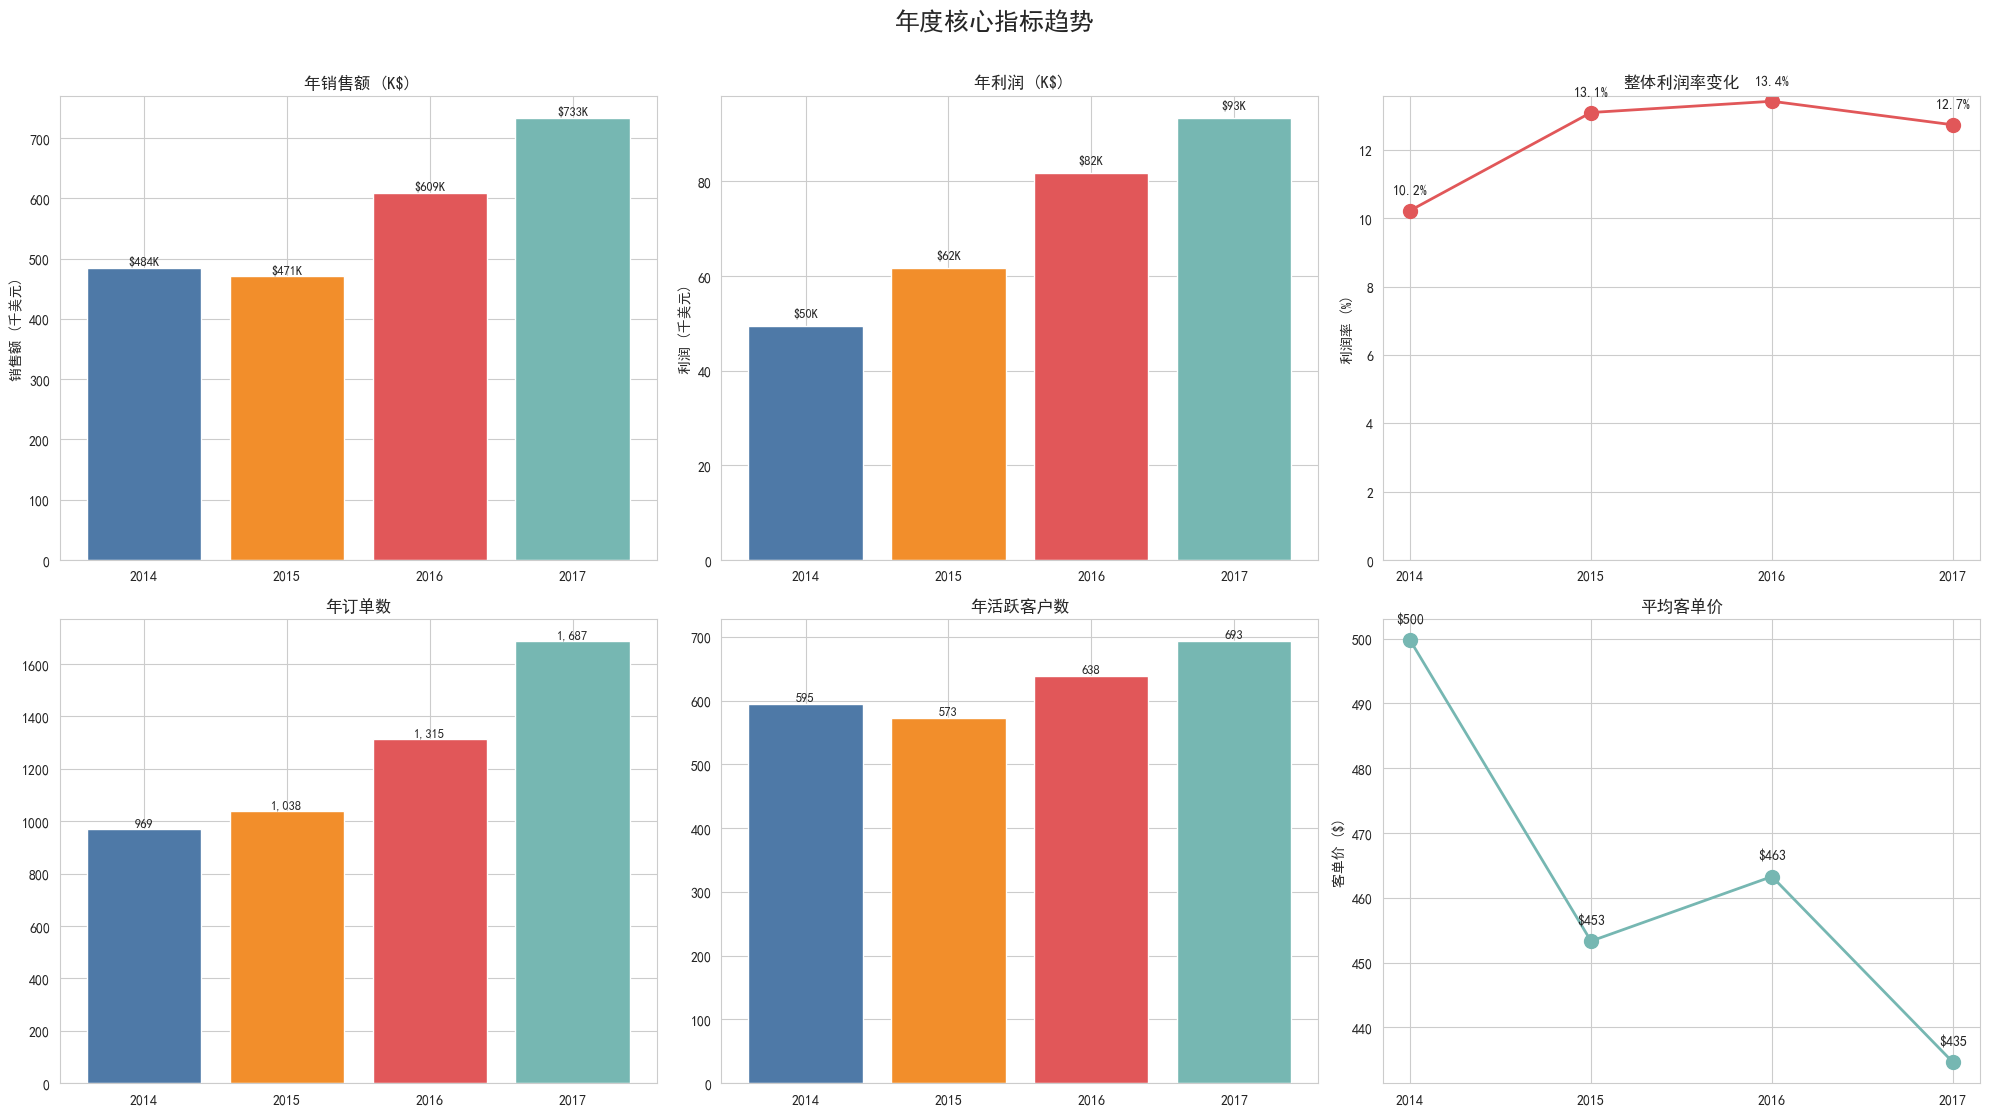

In [132]:
sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# --- 1.4 年度趋势可视化 ---
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('年度核心指标趋势', fontsize=18, fontweight='bold', y=1.01)

# 销售额趋势
ax = axes[0, 0]
colors = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2']
sales_by_year = yearly_kpi['销售额']
bars = ax.bar(sales_by_year.index.astype(str), sales_by_year.values / 1e3, color=colors, edgecolor='white')
for bar, val in zip(bars, sales_by_year.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'${val/1e3:,.0f}K', ha='center', fontsize=9)
ax.set_title('年销售额 (K$)')
ax.set_ylabel('销售额 (千美元)')

# 利润趋势
ax = axes[0, 1]
profit_by_year = yearly_kpi['利润']
bars = ax.bar(profit_by_year.index.astype(str), profit_by_year.values / 1e3, color=colors, edgecolor='white')
for bar, val in zip(bars, profit_by_year.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'${val/1e3:,.0f}K', ha='center', fontsize=9)
ax.set_title('年利润 (K$)')
ax.set_ylabel('利润 (千美元)')

# 利润率
ax = axes[0, 2]
margin_by_year = yearly_kpi['利润率_%']
ax.plot(margin_by_year.index.astype(str), margin_by_year.values, 'o-', color='#E15759', linewidth=2, markersize=10)
for x, y in zip(margin_by_year.index.astype(str), margin_by_year.values):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords="offset points", xytext=(0, 12), ha='center', fontsize=10, fontweight='bold')
ax.set_title('整体利润率变化')
ax.set_ylabel('利润率 (%)')
ax.set_ylim(bottom=0)

# 订单数
ax = axes[1, 0]
orders_by_year = yearly_kpi['订单数']
bars = ax.bar(orders_by_year.index.astype(str), orders_by_year.values, color=colors, edgecolor='white')
for bar, val in zip(bars, orders_by_year.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{val:,}', ha='center', fontsize=9)
ax.set_title('年订单数')

# 客户数
ax = axes[1, 1]
cust_by_year = yearly_kpi['客户数']
bars = ax.bar(cust_by_year.index.astype(str), cust_by_year.values, color=colors, edgecolor='white')
for bar, val in zip(bars, cust_by_year.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:,}', ha='center', fontsize=9)
ax.set_title('年活跃客户数')

# 客单价
ax = axes[1, 2]
aov_by_year = yearly_kpi['客单价']
ax.plot(aov_by_year.index.astype(str), aov_by_year.values, 'o-', color='#76B7B2', linewidth=2, markersize=10)
for x, y in zip(aov_by_year.index.astype(str), aov_by_year.values):
    ax.annotate(f'${y:,.0f}', (x, y), textcoords="offset points", xytext=(0, 12), ha='center', fontsize=10)
ax.set_title('平均客单价')
ax.set_ylabel('客单价 ($)')

plt.tight_layout()
plt.show()

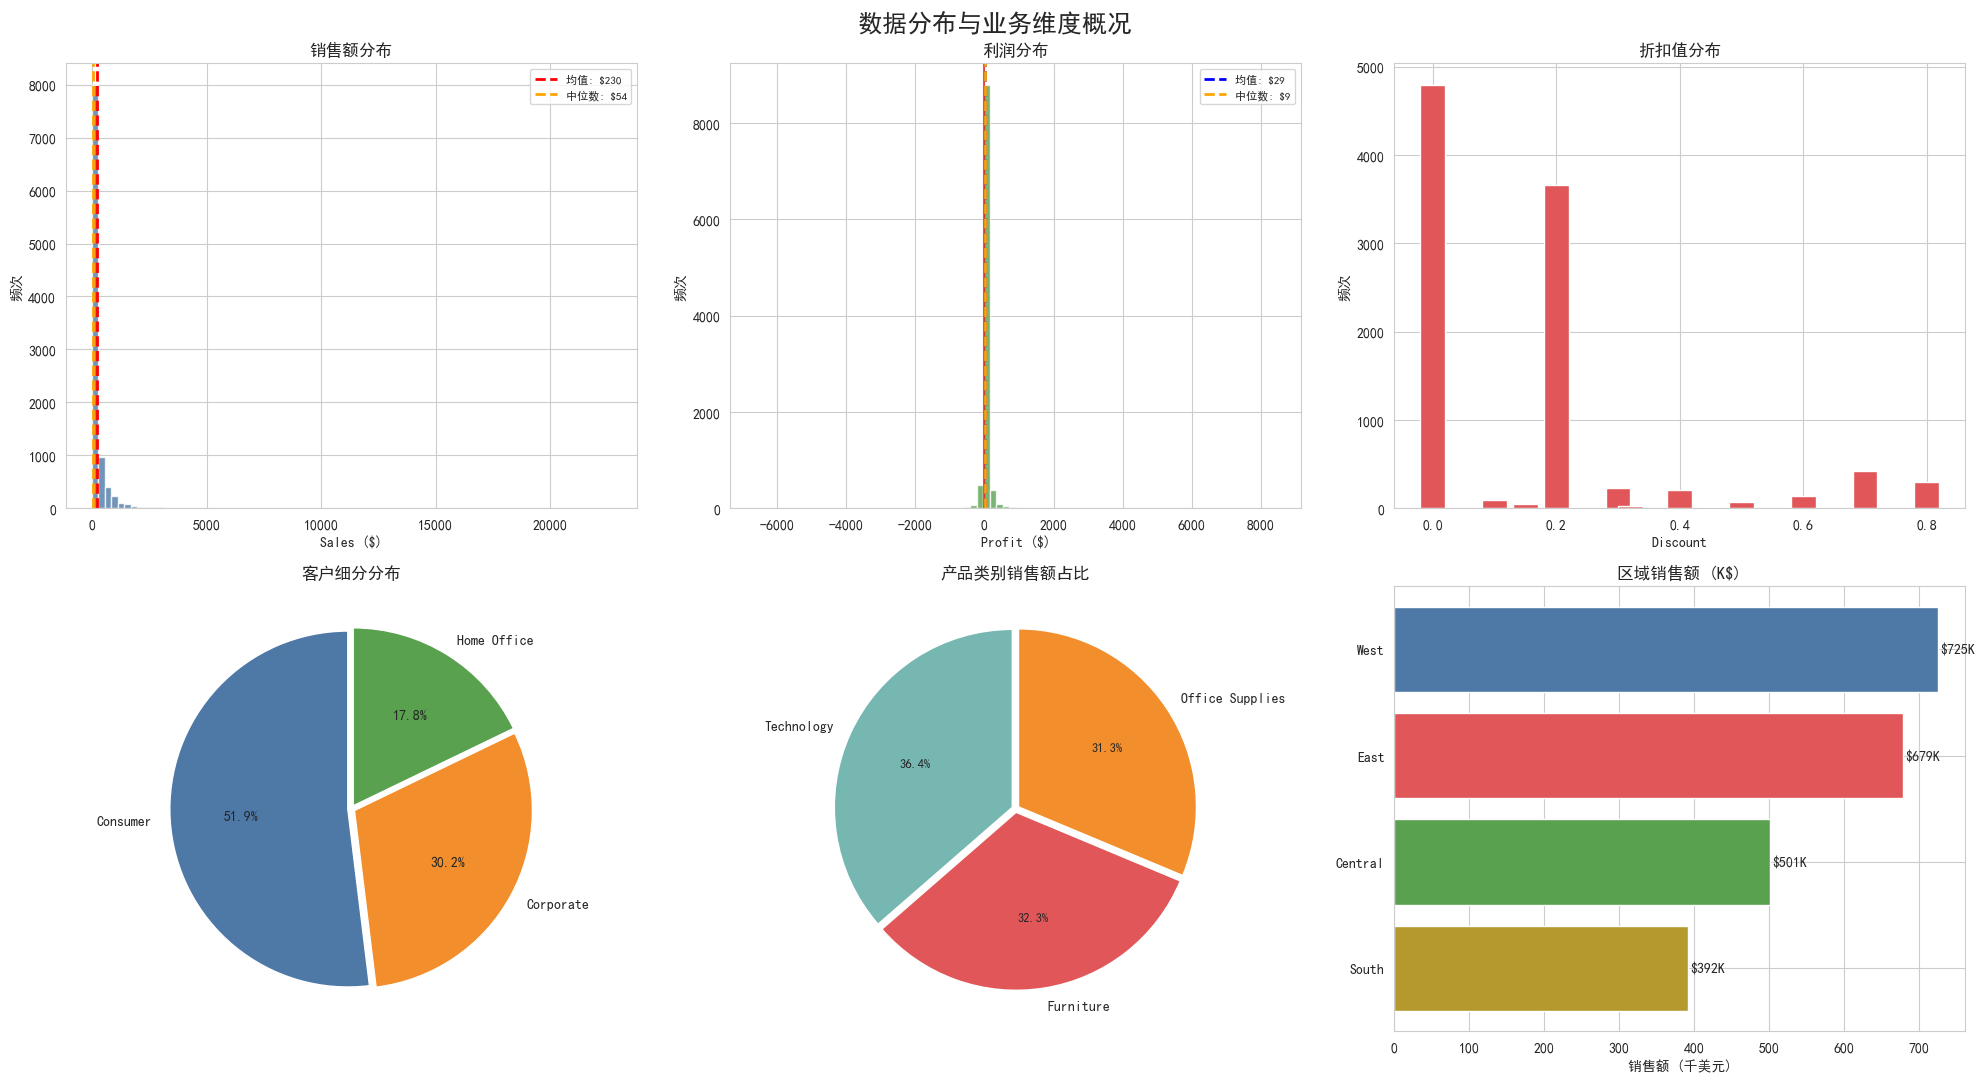

In [ ]:
# --- 1.5 数据分布与维度概况 ---
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('数据分布与业务维度概况', fontsize=18, fontweight='bold')

# Sales 分布
ax = axes[0, 0]
ax.hist(df['Sales'], bins=80, color='#4E79A7', edgecolor='white', alpha=0.8)
ax.axvline(df['Sales'].mean(), color='red', linestyle='--', linewidth=2, label=f'均值: ${df["Sales"].mean():,.0f}')
ax.axvline(df['Sales'].median(), color='orange', linestyle='--', linewidth=2, label=f'中位数: ${df["Sales"].median():,.0f}')
ax.set_title('销售额分布')
ax.set_xlabel('Sales ($)')
ax.set_ylabel('频次')
ax.legend(fontsize=8)

# Profit 分布
ax = axes[0, 1]
ax.hist(df['Profit'], bins=80, color='#59A14F', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='-', linewidth=1.5, alpha=0.7)
ax.axvline(df['Profit'].mean(), color='blue', linestyle='--', linewidth=2, label=f'均值: ${df["Profit"].mean():,.0f}')
ax.axvline(df['Profit'].median(), color='orange', linestyle='--', linewidth=2, label=f'中位数: ${df["Profit"].median():,.0f}')
ax.set_title('利润分布')
ax.set_xlabel('Profit ($)')
ax.set_ylabel('频次')
ax.legend(fontsize=8)

# Discount 分布
ax = axes[0, 2]
discount_counts = df['Discount'].value_counts().sort_index()
ax.bar(discount_counts.index, discount_counts.values, color='#E15759', edgecolor='white', width=0.04)
ax.set_title('折扣值分布')
ax.set_xlabel('Discount')
ax.set_ylabel('频次')

# Segment 分布
ax = axes[1, 0]
seg_counts = df['Segment'].value_counts()
colors_seg = ['#4E79A7', '#F28E2B', '#59A14F']
ax.pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%', colors=colors_seg,
       explode=(0.02, 0.02, 0.02), startangle=90)
ax.set_title('客户细分分布')

# Category 分布
ax = axes[1, 1]
cat_counts = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
colors_cat = ['#76B7B2', '#E15759', '#F28E2B']
wedges, texts, autotexts = ax.pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
                                   colors=colors_cat, explode=(0.02, 0.02, 0.02), startangle=90)
for t in autotexts: t.set_fontsize(9)
ax.set_title('产品类别销售额占比')

# Region 分布
ax = axes[1, 2]
reg_counts = df.groupby('Region')['Sales'].sum().sort_values(ascending=True)
colors_reg = ['#B6992D', '#59A14F', '#E15759', '#4E79A7']
bars = ax.barh(reg_counts.index, reg_counts.values / 1e3, color=colors_reg, edgecolor='white')
for bar, val in zip(bars, reg_counts.values):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2, f'${val/1e3:,.0f}K', va='center', fontsize=10)
ax.set_title('区域销售额 (K$)')
ax.set_xlabel('销售额 (千美元)')

plt.tight_layout()
plt.show()

### 销售趋势与时间序列分析

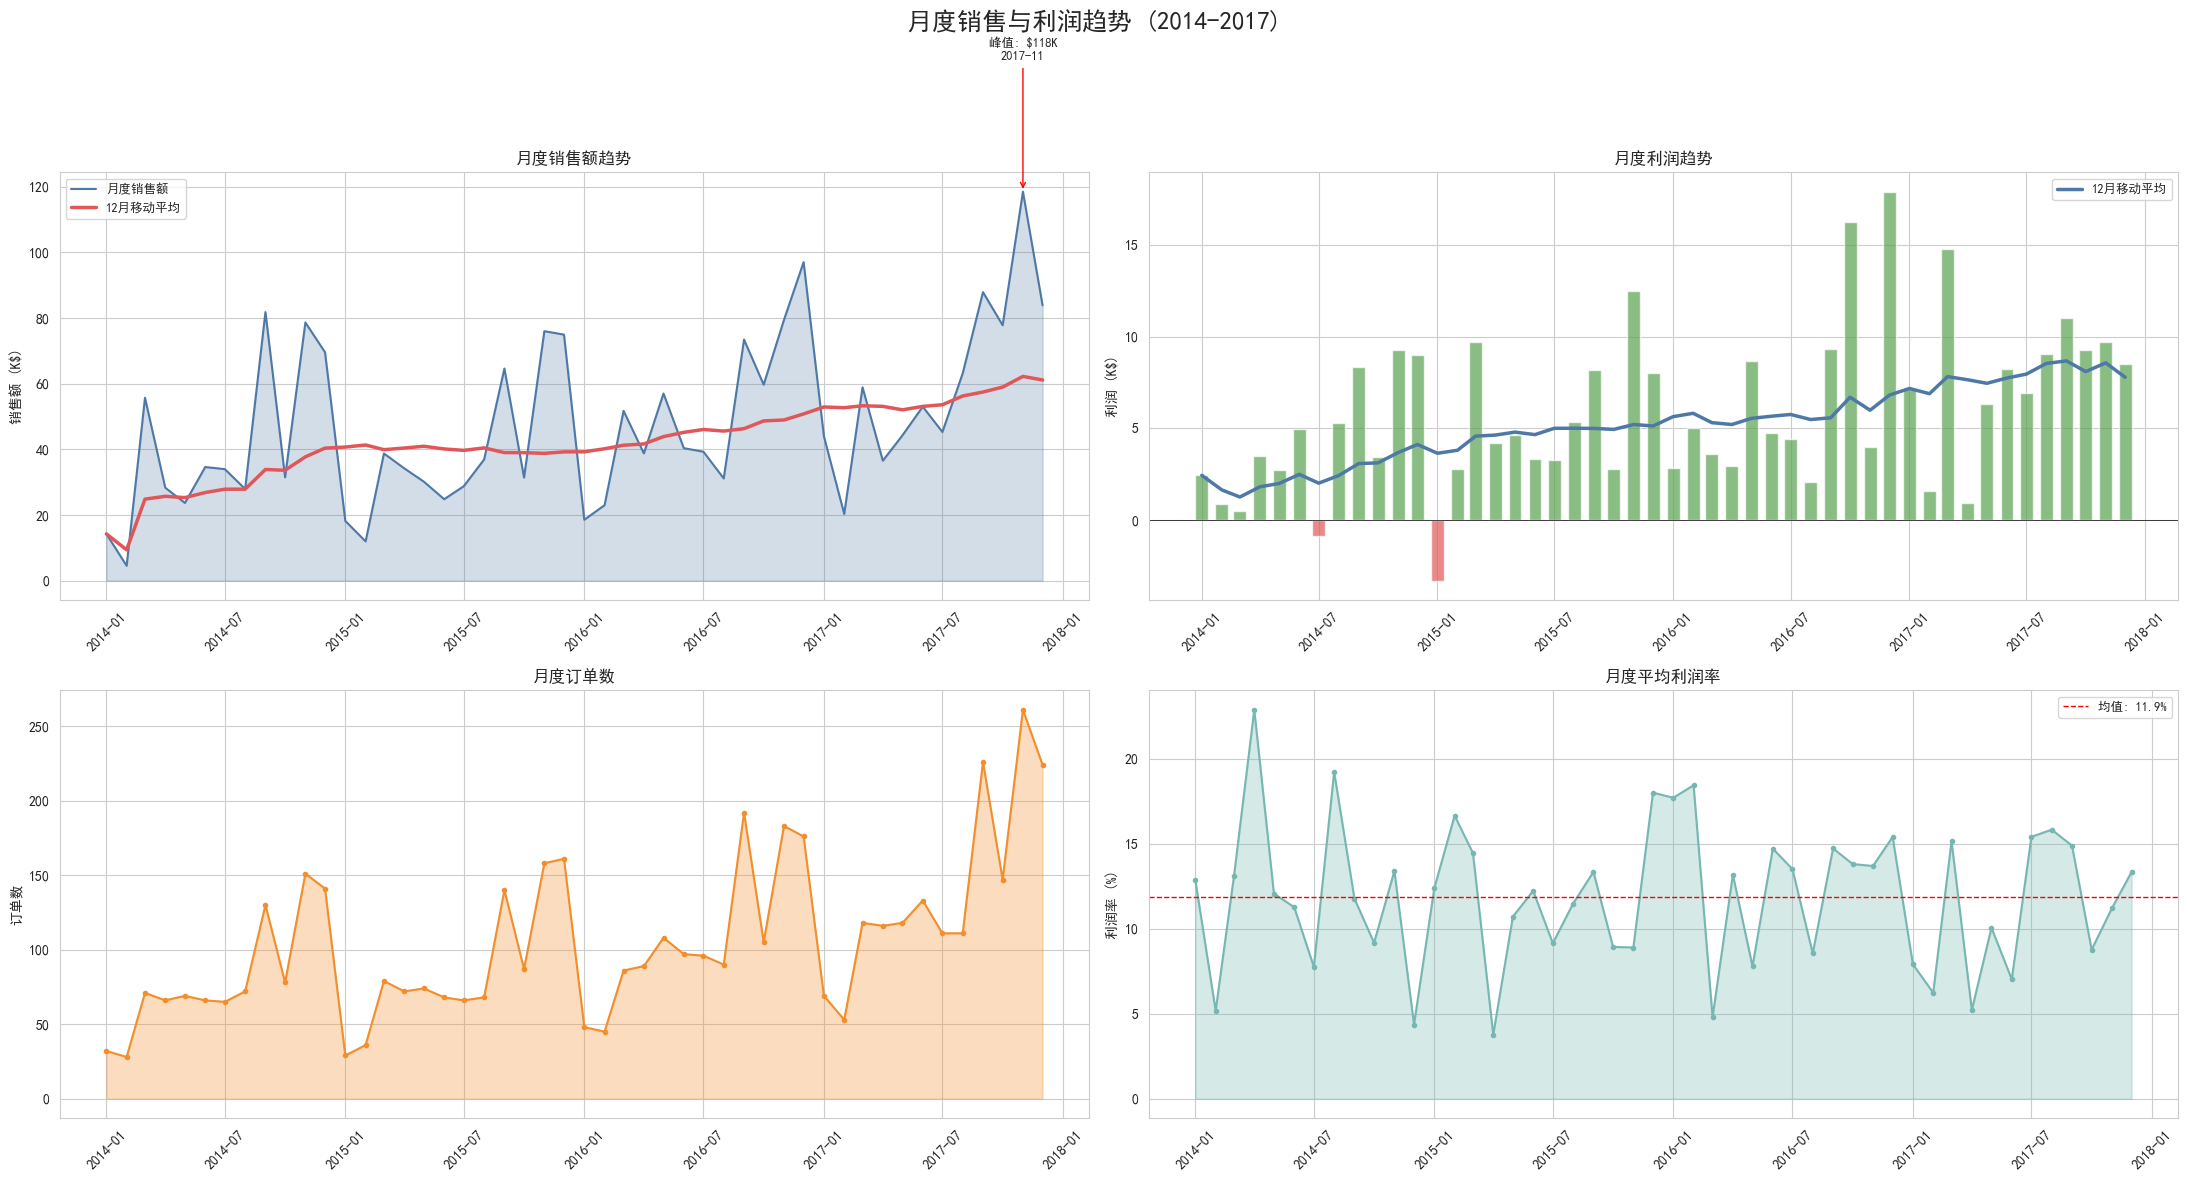

销售同比增长率统计（排除第一年）：
  平均月同比增长率: 27.2%
  最高增长率: 164.4% (2015-02)
  最低增长率: -30.5% (2015-03)


In [134]:
# --- 2.1 月度销售与利润趋势 ---
# 按月聚合
monthly = df.groupby('Order Year-Month').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique'),
    Customers=('Customer ID', 'nunique'),
    Avg_Discount=('Discount', 'mean'),
    Profit_Margin=('Profit Margin', 'mean')
).reset_index()
monthly['Order Year-Month'] = pd.to_datetime(monthly['Order Year-Month'].astype(str) + '-01')
monthly = monthly.sort_values('Order Year-Month')

# 计算12个月移动平均
monthly['Sales_MA12'] = monthly['Sales'].rolling(window=12, min_periods=1).mean()
monthly['Profit_MA12'] = monthly['Profit'].rolling(window=12, min_periods=1).mean()

fig, axes = plt.subplots(2, 2, figsize=(22, 12))
fig.suptitle('月度销售与利润趋势 (2014-2017)', fontsize=18, fontweight='bold')

# Sales 趋势
ax = axes[0, 0]
ax.fill_between(monthly['Order Year-Month'], monthly['Sales']/1e3, alpha=0.25, color='#4E79A7')
ax.plot(monthly['Order Year-Month'], monthly['Sales']/1e3, color='#4E79A7', linewidth=1.5, label='月度销售额')
ax.plot(monthly['Order Year-Month'], monthly['Sales_MA12']/1e3, color='#E15759', linewidth=2.5, label='12月移动平均')
peak_month = monthly.loc[monthly['Sales'].idxmax()]
ax.annotate(f'峰值: ${peak_month["Sales"]/1e3:,.0f}K\n{peak_month["Order Year-Month"].strftime("%Y-%m")}',
            xy=(peak_month['Order Year-Month'], peak_month['Sales']/1e3),
            xytext=(peak_month['Order Year-Month'], peak_month['Sales']/1e3 + 40),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=9, ha='center')
ax.set_title('月度销售额趋势')
ax.set_ylabel('销售额 (K$)')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=45)

# Profit 趋势
ax = axes[0, 1]
profit_colors = ['#59A14F' if v >= 0 else '#E15759' for v in monthly['Profit']]
ax.bar(monthly['Order Year-Month'], monthly['Profit']/1e3, color=profit_colors, alpha=0.7, width=20)
ax.plot(monthly['Order Year-Month'], monthly['Profit_MA12']/1e3, color='#4E79A7', linewidth=2.5, label='12月移动平均')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('月度利润趋势')
ax.set_ylabel('利润 (K$)')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=45)

# 月度订单数
ax = axes[1, 0]
ax.fill_between(monthly['Order Year-Month'], monthly['Orders'], alpha=0.3, color='#F28E2B')
ax.plot(monthly['Order Year-Month'], monthly['Orders'], color='#F28E2B', linewidth=1.5, marker='o', markersize=3)
ax.set_title('月度订单数')
ax.set_ylabel('订单数')
ax.tick_params(axis='x', rotation=45)

# 平均利润率
ax = axes[1, 1]
ax.fill_between(monthly['Order Year-Month'], monthly['Profit_Margin']*100, alpha=0.3, color='#76B7B2')
ax.plot(monthly['Order Year-Month'], monthly['Profit_Margin']*100, color='#76B7B2', linewidth=1.5, marker='o', markersize=3)
ax.axhline(y=monthly['Profit_Margin'].mean()*100, color='red', linestyle='--', linewidth=1, label=f'均值: {monthly["Profit_Margin"].mean()*100:.1f}%')
ax.set_title('月度平均利润率')
ax.set_ylabel('利润率 (%)')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 同比增长率计算
monthly['Sales_YoY'] = monthly['Sales'].pct_change(periods=12) * 100
print("销售同比增长率统计（排除第一年）：")
yoy_stats = monthly.dropna(subset=['Sales_YoY'])
print(f"  平均月同比增长率: {yoy_stats['Sales_YoY'].mean():.1f}%")
print(f"  最高增长率: {yoy_stats['Sales_YoY'].max():.1f}% ({yoy_stats.loc[yoy_stats['Sales_YoY'].idxmax(), 'Order Year-Month'].strftime('%Y-%m')})")
print(f"  最低增长率: {yoy_stats['Sales_YoY'].min():.1f}% ({yoy_stats.loc[yoy_stats['Sales_YoY'].idxmin(), 'Order Year-Month'].strftime('%Y-%m')})")

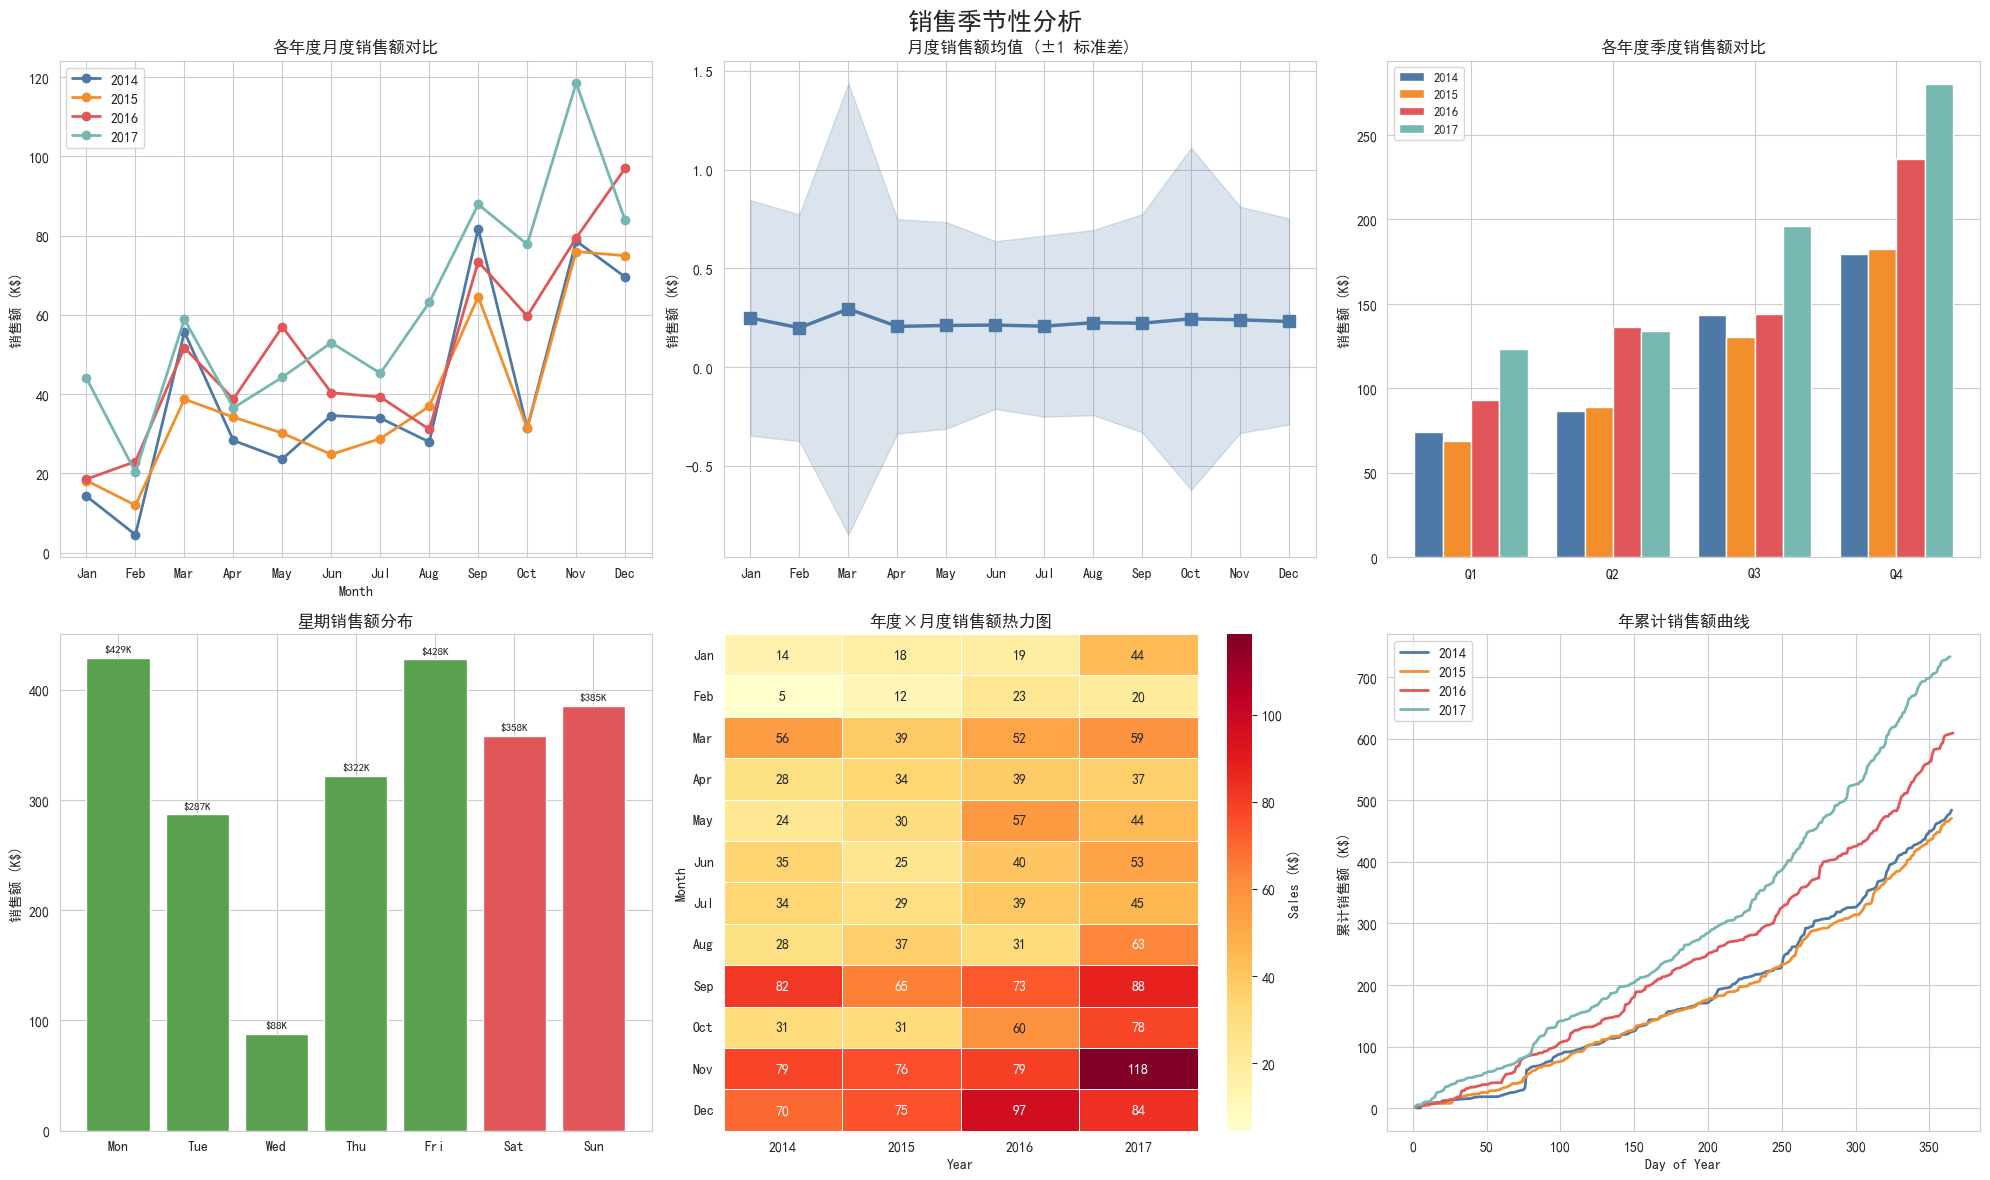

季度同比分析：
                 Sales   Profit  Profit_Margin_%
Year Quarter                                    
2014 1         74448.0   3811.0             5.12
     2         86539.0  11204.0            12.95
     3        143633.0  12805.0             8.92
     4        179628.0  21724.0            12.09
2015 1         68852.0   9265.0            13.46
     2         89124.0  12191.0            13.68
     3        130260.0  16854.0            12.94
     4        182297.0  23309.0            12.79
2016 1         93237.0  11441.0            12.27
     2        136082.0  16390.0            12.04
     3        143787.0  15824.0            11.01
     4        236099.0  38140.0            16.15
2017 1        123145.0  23506.0            19.09
     2        133764.0  15499.0            11.59
     3        196252.0  26985.0            13.75
     4        280054.0  27449.0             9.80


In [135]:
# --- 2.2 季节性分析 ---
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('销售季节性分析', fontsize=18, fontweight='bold')

# 按月聚合多年平均
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_season = df.groupby(['Year', 'Month']).agg(Sales=('Sales', 'sum')).reset_index()
monthly_pivot = monthly_season.pivot(index='Month', columns='Year', values='Sales')
monthly_avg = df.groupby('Month')['Sales'].mean()

ax = axes[0, 0]
years = sorted(df['Year'].unique())
colors_year = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2']
for i, year in enumerate(years):
    if year in monthly_pivot.columns:
        ax.plot(monthly_pivot.index, monthly_pivot[year]/1e3, color=colors_year[i],
                linewidth=2, marker='o', markersize=6, label=f'{year}')
ax.set_title('各年度月度销售额对比')
ax.set_xlabel('Month')
ax.set_ylabel('销售额 (K$)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.legend()

# 月度均值（带标准差）
ax = axes[0, 1]
monthly_std = df.groupby('Month')['Sales'].std()
ax.fill_between(range(1, 13), (monthly_avg - monthly_std)/1e3, (monthly_avg + monthly_std)/1e3,
                 alpha=0.2, color='#4E79A7')
ax.plot(range(1, 13), monthly_avg.values/1e3, color='#4E79A7', linewidth=2.5, marker='s', markersize=8)
ax.set_title('月度销售额均值 (±1 标准差)')
ax.set_ylabel('销售额 (K$)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)

# 季度分布
ax = axes[0, 2]
qtr_data = df.groupby(['Year', 'Quarter'])['Sales'].sum().reset_index()
qtr_pivot = qtr_data.pivot(index='Quarter', columns='Year', values='Sales')
x = np.arange(4)
width = 0.2
for i, year in enumerate(years):
    if year in qtr_pivot.columns:
        bars = ax.bar(x + i*width, qtr_pivot[year]/1e3, width, label=str(year), color=colors_year[i])
ax.set_title('各年度季度销售额对比')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
ax.set_ylabel('销售额 (K$)')
ax.legend(fontsize=9)

# 周内分布
ax = axes[1, 0]
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_sales = df.groupby('Weekday')['Sales'].sum().reindex(weekday_order)
bars = ax.bar(range(7), weekday_sales.values/1e3, color=['#59A14F' if i<5 else '#E15759' for i in range(7)], edgecolor='white')
for bar, val in zip(bars, weekday_sales.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'${val/1e3:,.0f}K', ha='center', fontsize=8)
ax.set_title('星期销售额分布')
ax.set_xticks(range(7))
ax.set_xticklabels([d[:3] for d in weekday_order])
ax.set_ylabel('销售额 (K$)')

# 年度热力图
ax = axes[1, 1]
pivot_heatmap = monthly_season.pivot(index='Month', columns='Year', values='Sales')
sns.heatmap(pivot_heatmap/1e3, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Sales (K$)'})
ax.set_title('年度×月度销售额热力图')
ax.set_yticklabels(month_names, rotation=0)

# 年累计销售额曲线
ax = axes[1, 2]
for year in years:
    year_data = df[df['Year'] == year].copy()
    year_data['DayOfYear'] = year_data['Order Date'].dt.dayofyear
    daily_cumsum = year_data.groupby('DayOfYear')['Sales'].sum().cumsum()
    ax.plot(daily_cumsum.index, daily_cumsum.values/1e3, color=colors_year[year-2014], linewidth=2, label=f'{year}')
ax.set_title('年累计销售额曲线')
ax.set_xlabel('Day of Year')
ax.set_ylabel('累计销售额 (K$)')
ax.legend()

plt.tight_layout()
plt.show()

# 季度同比分析
print("季度同比分析：")
qtr_summary = df.groupby(['Year', 'Quarter']).agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum')).round(0)
qtr_summary['Profit_Margin_%'] = (qtr_summary['Profit'] / qtr_summary['Sales'] * 100).round(2)
print(qtr_summary.to_string())

In [136]:
# --- 2.3 增长驱动因子分解 ---
# 将 Sales = Order_Count × Avg_Order_Value
yearly_drivers = df.groupby('Year').agg(
    Sales=('Sales', 'sum'),
    Orders=('Order ID', 'nunique'),
    Customers=('Customer ID', 'nunique')
)
yearly_drivers['AOV'] = yearly_drivers['Sales'] / yearly_drivers['Orders']
yearly_drivers['Orders_per_Customer'] = yearly_drivers['Orders'] / yearly_drivers['Customers']

print("增长驱动因子分解：")
print(f"{'指标':<20} {'2014':>12} {'2015':>12} {'2016':>12} {'2017':>12}")
print("-" * 70)
for col in ['Sales', 'Orders', 'Customers', 'AOV', 'Orders_per_Customer']:
    vals = yearly_drivers[col]
    if col == 'Sales':
        print(f"{col:<20} {vals[2014]:>12,.0f} {vals[2015]:>12,.00f} {vals[2016]:>12,.0f} {vals[2017]:>12,.0f}")
    elif col == 'AOV':
        print(f"{col:<20} {vals[2014]:>12,.2f} {vals[2015]:>12,.2f} {vals[2016]:>12,.2f} {vals[2017]:>12,.2f}")
    elif col == 'Orders_per_Customer':
        print(f"{col:<20} {vals[2014]:>12.2f} {vals[2015]:>12.2f} {vals[2016]:>12.2f} {vals[2017]:>12.2f}")
    else:
        print(f"{col:<20} {vals[2014]:>12,.0f} {vals[2015]:>12,.0f} {vals[2016]:>12,.0f} {vals[2017]:>12,.0f}")

# 各类别增长贡献
print("\n各类别对总增长贡献：")
cat_trend = df.groupby(['Year', 'Category'])['Sales'].sum().unstack()
cat_growth = cat_trend.diff()
total_growth = cat_trend.sum(axis=1).diff()
for year in [2015, 2016, 2017]:
    print(f"\n  {year} 年增长贡献率：")
    for cat in cat_growth.columns:
        contrib = cat_growth.loc[year, cat] / total_growth.loc[year] * 100
        print(f"    {cat}: {contrib:+.1f}%")

增长驱动因子分解：
指标                           2014         2015         2016         2017
----------------------------------------------------------------------
Sales                     484,247      470,533      609,206      733,215
Orders                        969        1,038        1,315        1,687
Customers                     595          573          638          693
AOV                        499.74       453.31       463.27       434.63
Orders_per_Customer          1.63         1.81         2.06         2.43

各类别对总增长贡献：

  2015 年增长贡献率：
    Furniture: -97.2%
    Office Supplies: +106.0%
    Technology: +91.1%

  2016 年增长贡献率：
    Furniture: +20.5%
    Office Supplies: +33.7%
    Technology: +45.9%

  2017 年增长贡献率：
    Furniture: +13.3%
    Office Supplies: +50.1%
    Technology: +36.6%


### 产品结构与利润分析

In [137]:
# --- 3.1 产品层级分析：Category → Sub-Category 钻取 ---
# Sub-Category 级别指标
subcat_stats = df.groupby('Sub-Category').agg(
    Category=('Category', 'first'),
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum'),
    Orders=('Order ID', 'nunique'),
    Avg_Discount=('Discount', 'mean'),
    Avg_Price=('Sales', 'mean')
).round(2)
subcat_stats['Profit_Margin_%'] = (subcat_stats['Profit'] / subcat_stats['Sales'] * 100).round(2)
subcat_stats['Sales_Share_%'] = (subcat_stats['Sales'] / total_sales * 100).round(2)
subcat_stats['Profit_Share_%'] = (subcat_stats['Profit'] / total_profit * 100).round(2)

# 按利润率和销售额排序
print("=" * 80)
print("  Sub-Category 产品绩效总览（按利润率排序）")
print("=" * 80)
display_cols = ['Category', 'Sales', 'Profit', 'Profit_Margin_%', 'Sales_Share_%', 'Profit_Share_%', 'Avg_Discount', 'Orders']
print(subcat_stats[display_cols].sort_values('Profit_Margin_%', ascending=False).to_string())

# Category 汇总
cat_stats = df.groupby('Category').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum'),
    Orders=('Order ID', 'nunique')
)
cat_stats['Profit_Margin_%'] = (cat_stats['Profit'] / cat_stats['Sales'] * 100).round(2)
cat_stats['Sales_Share_%'] = (cat_stats['Sales'] / total_sales * 100).round(2)
print("\n" + "=" * 50)
print("  Category 级别汇总")
print("=" * 50)
print(cat_stats.to_string())

  Sub-Category 产品绩效总览（按利润率排序）
                     Category      Sales    Profit  Profit_Margin_%  Sales_Share_%  Profit_Share_%  Avg_Discount  Orders
Sub-Category                                                                                                            
Labels        Office Supplies   12486.31   5546.25            44.42           0.54            1.94          0.07     346
Paper         Office Supplies   78479.21  34053.57            43.39           3.42           11.89          0.07    1191
Envelopes     Office Supplies   16476.40   6964.18            42.27           0.72            2.43          0.08     249
Copiers            Technology  149528.03  55617.82            37.20           6.51           19.42          0.16      68
Fasteners     Office Supplies    3024.28    949.52            31.40           0.13            0.33          0.08     215
Accessories        Technology  167380.32  41936.64            25.05           7.29           14.64          0.08     718
Ar

In [138]:
# --- 3.1b 产品可视化：树状图 + 帕累托图 ---
# 尝试使用 plotly 绘制树状图
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
except:
    PLOTLY_AVAILABLE = False
    print("plotly 不可用，将使用 matplotlib 替代")

if PLOTLY_AVAILABLE:
    # 树状图：Category → Sub-Category 的 Sales 占比
    treemap_data = subcat_stats.reset_index()
    fig = px.treemap(
        treemap_data,
        path=[px.Constant('All'), 'Category', 'Sub-Category'],
        values='Sales',
        color='Profit_Margin_%',
        color_continuous_scale='RdYlGn',
        color_continuous_midpoint=0,
        hover_data={'Profit': ':$,.0f', 'Sales_Share_%': ':.1f', 'Profit_Margin_%': ':.1f'},
        title='产品树状图：Category → Sub-Category (大小=销售额, 颜色=利润率)'
    )
    fig.update_traces(textinfo='label+percent parent')
    fig.update_layout(height=600)
    fig.show()
else:
    pass

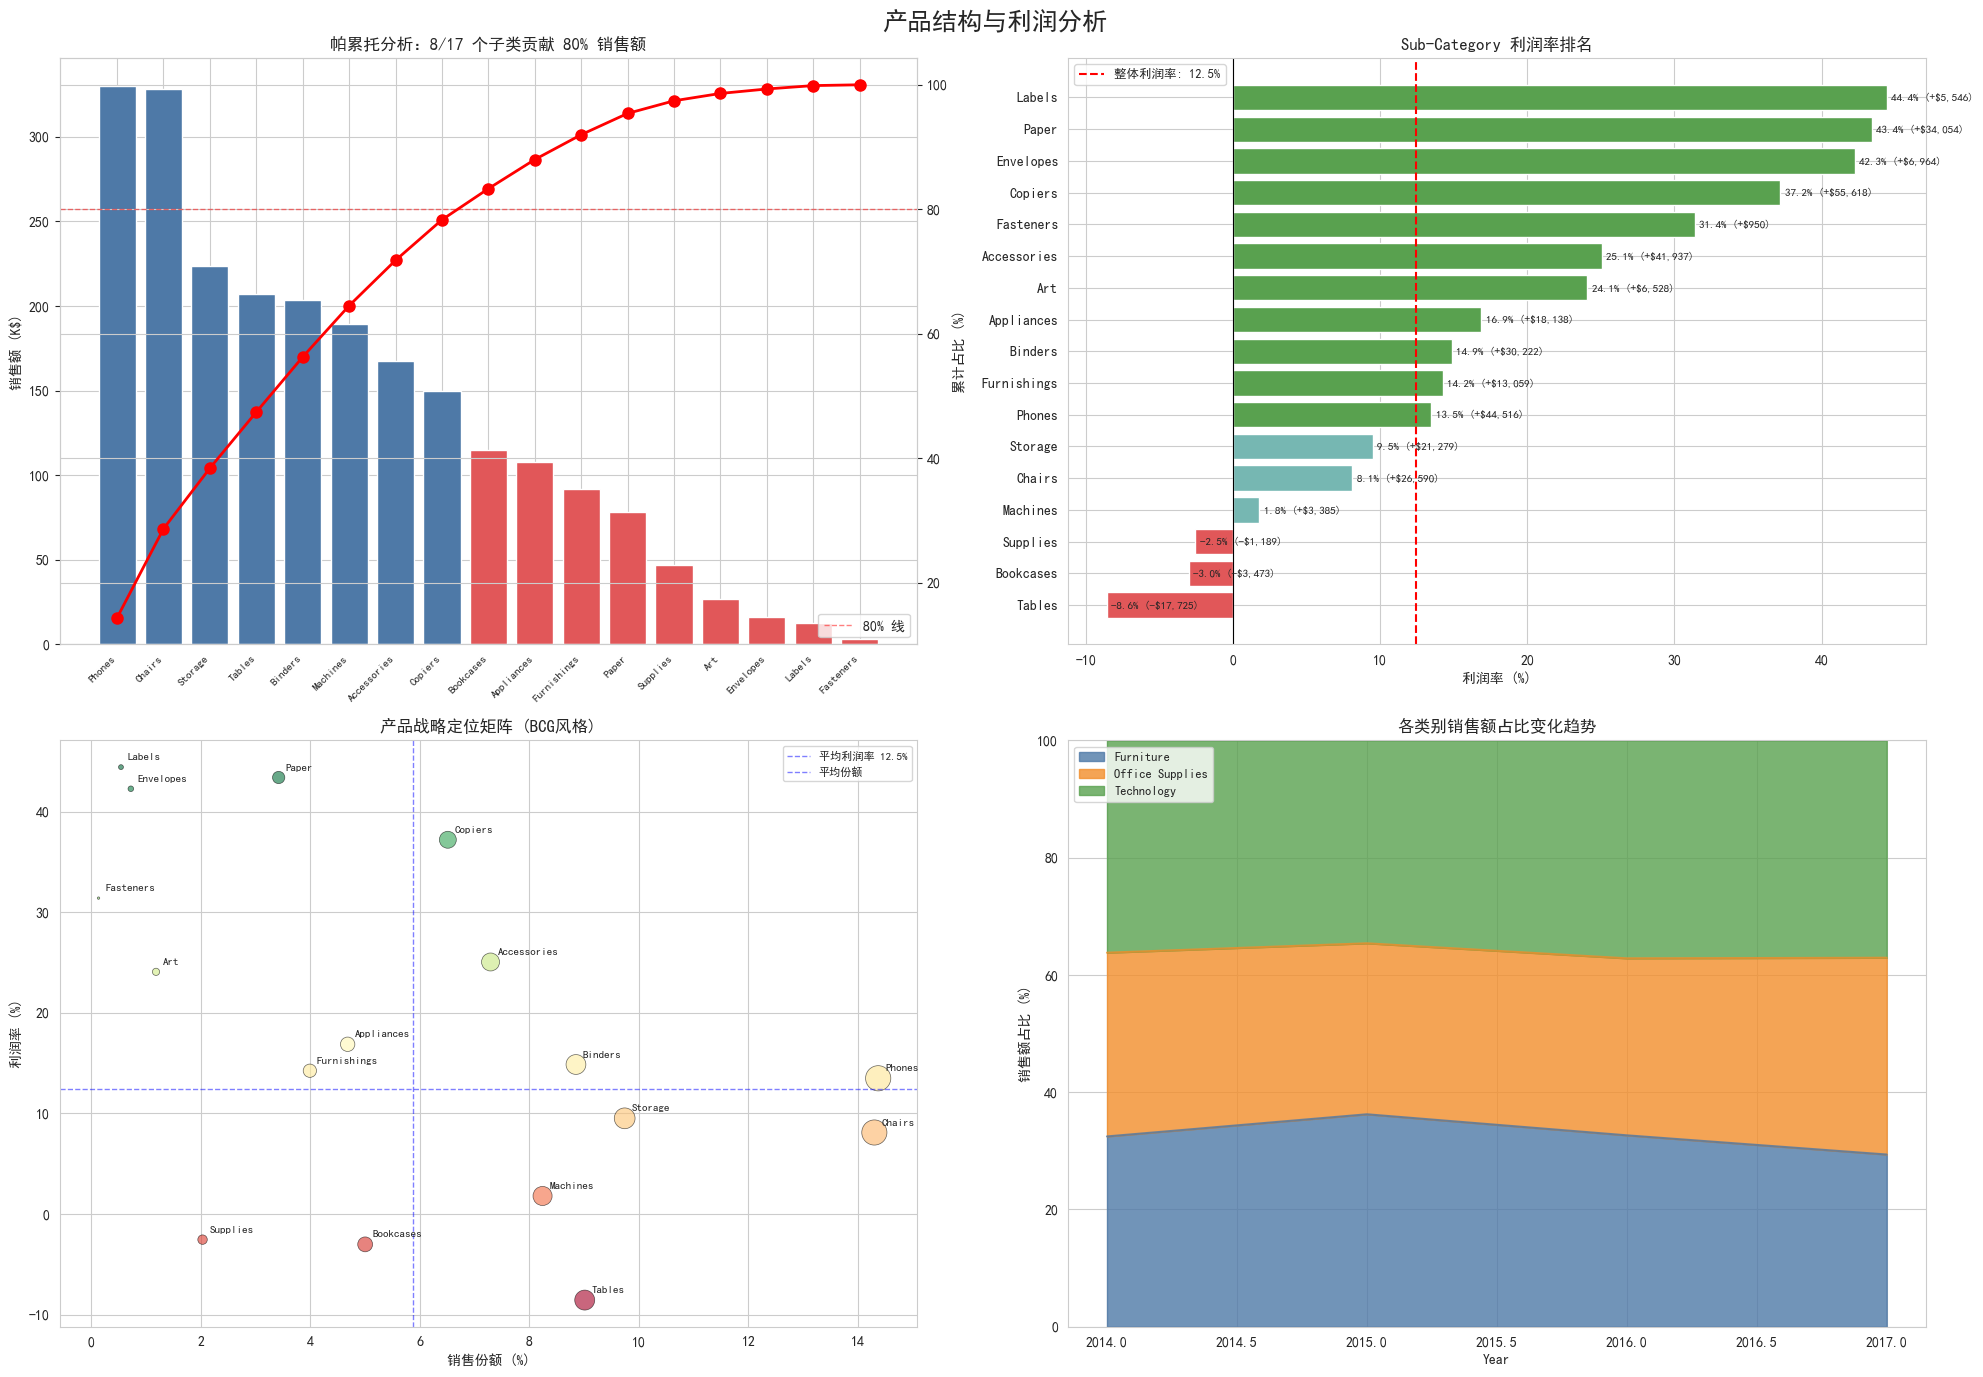

In [139]:
# --- 3.1c 帕累托分析 (80/20 法则) + 产品矩阵 ---
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('产品结构与利润分析', fontsize=18, fontweight='bold')

# 帕累托图：Sub-Category
ax = axes[0, 0]
pareto_data = subcat_stats.sort_values('Sales', ascending=False)
pareto_data['Cumulative_%'] = pareto_data['Sales'].cumsum() / pareto_data['Sales'].sum() * 100
colors_pareto = ['#4E79A7' if c <= 80 else '#E15759' for c in pareto_data['Cumulative_%']]
bars = ax.bar(range(len(pareto_data)), pareto_data['Sales']/1e3, color=colors_pareto, edgecolor='white')
ax2 = ax.twinx()
ax2.plot(range(len(pareto_data)), pareto_data['Cumulative_%'], 'o-', color='red', linewidth=2, markersize=8)
ax2.axhline(y=80, color='red', linestyle='--', linewidth=1, alpha=0.5, label='80% 线')
n80 = (pareto_data['Cumulative_%'] <= 80).sum()
ax.set_xticks(range(len(pareto_data)))
ax.set_xticklabels(pareto_data.index, rotation=45, ha='right', fontsize=8)
ax.set_title(f'帕累托分析：{n80}/17 个子类贡献 80% 销售额')
ax.set_ylabel('销售额 (K$)')
ax2.set_ylabel('累计占比 (%)')
ax2.legend(loc='lower right')

# Sub-Category 利润率对比
ax = axes[0, 1]
profit_by_subcat = subcat_stats.sort_values('Profit_Margin_%')
colors_subcat = ['#E15759' if v < 0 else '#76B7B2' if v < 10 else '#59A14F' for v in profit_by_subcat['Profit_Margin_%']]
bars = ax.barh(profit_by_subcat.index, profit_by_subcat['Profit_Margin_%'], color=colors_subcat, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.axvline(x=overall_margin, color='red', linestyle='--', linewidth=1.5, label=f'整体利润率: {overall_margin:.1f}%')
for bar, (margin, profit) in enumerate(zip(profit_by_subcat['Profit_Margin_%'], profit_by_subcat['Profit'])):
    sign = '+' if profit >= 0 else '-'
    ax.text(margin + 0.3, bar, f'{margin:.1f}% ({sign}${abs(profit):,.0f})', va='center', fontsize=8)
ax.set_title('Sub-Category 利润率排名')
ax.set_xlabel('利润率 (%)')
ax.legend(fontsize=9)

# Sales vs Profit Margin 气泡散点图 (BCG风格)
ax = axes[1, 0]
scatter_data = subcat_stats.copy()
ax.scatter(scatter_data['Sales_Share_%'], scatter_data['Profit_Margin_%'],
           s=scatter_data['Sales']/1000, alpha=0.6, c=scatter_data['Profit_Margin_%'],
           cmap='RdYlGn', edgecolors='black', linewidth=0.5)
ax.axhline(y=overall_margin, color='blue', linestyle='--', linewidth=1, alpha=0.5, label=f'平均利润率 {overall_margin:.1f}%')
ax.axvline(x=100/17, color='blue', linestyle='--', linewidth=1, alpha=0.5, label='平均份额')
# 标注每个点
for subcat, row in scatter_data.iterrows():
    ax.annotate(subcat, (row['Sales_Share_%'], row['Profit_Margin_%']),
                textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.set_xlabel('销售份额 (%)')
ax.set_ylabel('利润率 (%)')
ax.set_title('产品战略定位矩阵 (BCG风格)')
ax.legend(fontsize=8)

# Category 维度对比
ax = axes[1, 1]
cat_comp = df.groupby(['Category', 'Year'])['Sales'].sum().unstack()
cat_comp_pct = cat_comp.div(cat_comp.sum(axis=0), axis=1) * 100
cat_colors = ['#4E79A7', '#F28E2B', '#59A14F']
cat_comp_pct.T.plot(kind='area', stacked=True, ax=ax, color=cat_colors, alpha=0.8)
ax.set_title('各类别销售额占比变化趋势')
ax.set_xlabel('Year')
ax.set_ylabel('销售额占比 (%)')
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

折扣带影响分析：
                  Rows  Total_Sales  Total_Profit  Avg_Profit_Margin  Avg_Quantity  Avg_Sales  Profit_Margin_%  Sales_Share_%  Row_Pct_%
Discount_Band                                                                                                                           
No Discount (0%)  4798   1087908.47     320987.60               0.34          3.81     226.74            29.51          47.36      48.01
Low (0-20%)       3803    846522.24     100785.47               0.17          3.74     222.59            11.91          36.85      38.05
Medium (20-40%)    460    234137.90     -35817.47              -0.17          3.78     509.00           -15.30          10.19       4.60
High (40-60%)      215     71048.21     -28944.19              -0.63          3.66     330.46           -40.74           3.09       2.15
Very High (60%+)   718     57584.04     -70614.40              -1.23          3.97      80.20          -122.63           2.51       7.18


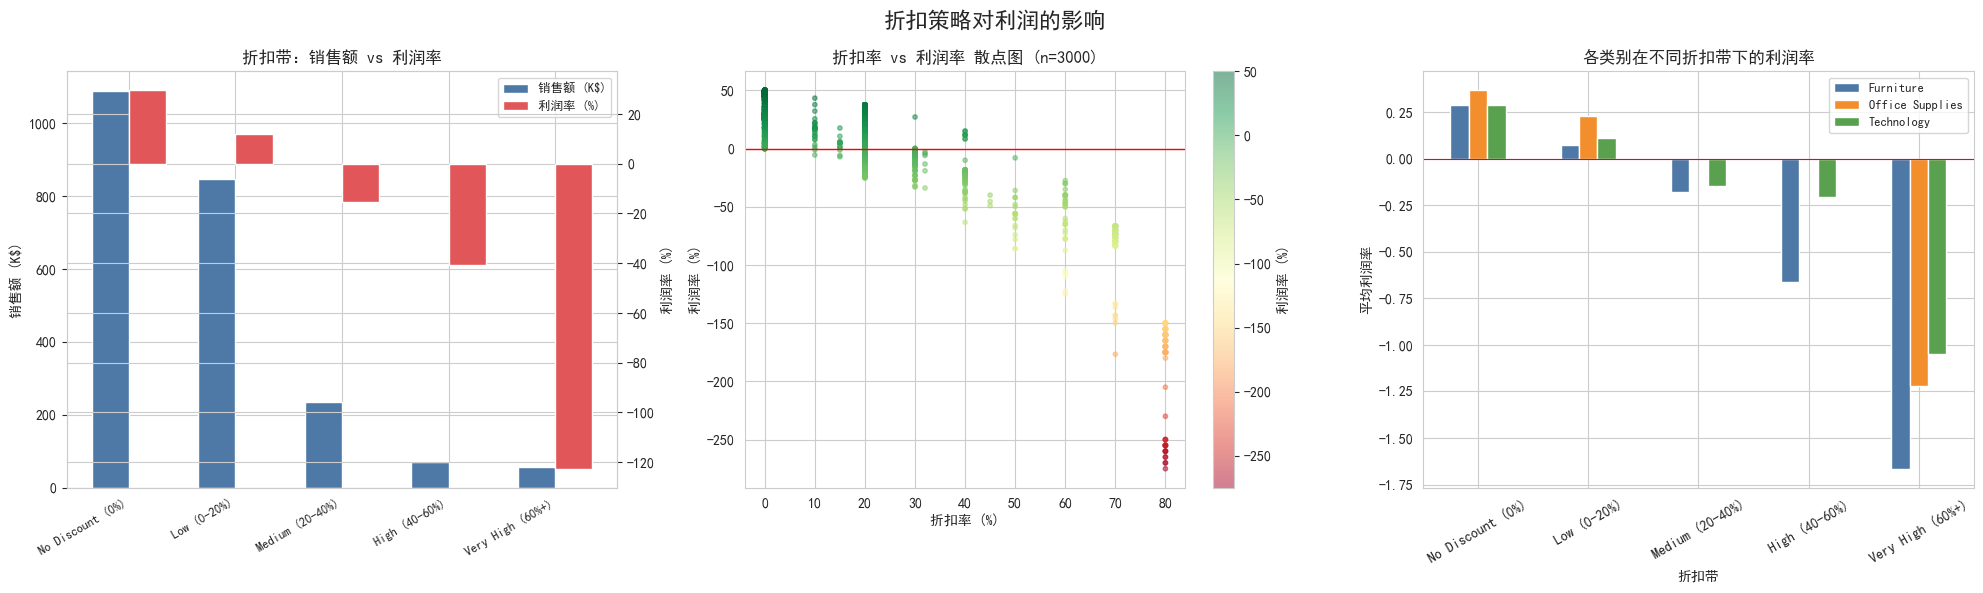


利润杀手清单：高折扣导致严重亏损的 Sub-Category
              Orders  Avg_Discount  Total_Profit  Avg_Profit_Margin  Avg_Profit_Margin_%
Sub-Category                                                                            
Binders          526        0.7380   -38510.4964            -1.0781              -107.81
Tables           168        0.3929   -30698.2228            -0.3448               -34.48
Machines          50        0.5434   -29555.3521            -0.5070               -50.70
Bookcases         69        0.4449   -11097.7614            -0.5976               -59.76
Appliances        65        0.8000    -8629.6412            -2.5336              -253.36
Chairs           149        0.3000    -6737.1167            -0.1163               -11.63
Phones            98        0.4000    -6385.7854            -0.1873               -18.73
Furnishings      127        0.6000    -5944.6552            -0.6891               -68.91


In [140]:
# --- 3.2 折扣影响深度分析 ---
# 折扣分段
bins = [-0.01, 0, 0.2, 0.4, 0.6, 1.0]
labels = ['No Discount (0%)', 'Low (0-20%)', 'Medium (20-40%)', 'High (40-60%)', 'Very High (60%+)']
df['Discount_Band'] = pd.cut(df['Discount'], bins=bins, labels=labels, right=True)

discount_impact = df.groupby('Discount_Band', observed=False).agg(
    Rows=('Sales', 'count'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Profit_Margin=('Profit Margin', 'mean'),
    Avg_Quantity=('Quantity', 'mean'),
    Avg_Sales=('Sales', 'mean')
).round(2)
discount_impact['Profit_Margin_%'] = (discount_impact['Total_Profit'] / discount_impact['Total_Sales'] * 100).round(2)
discount_impact['Sales_Share_%'] = (discount_impact['Total_Sales'] / discount_impact['Total_Sales'].sum() * 100).round(2)
discount_impact['Row_Pct_%'] = (discount_impact['Rows'] / discount_impact['Rows'].sum() * 100).round(2)

print("折扣带影响分析：")
print(discount_impact.to_string())

# 可视化：折扣与利润率关系
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('折扣策略对利润的影响', fontsize=16, fontweight='bold')

# 折扣带 - 销售额 vs 利润率
ax = axes[0]
x_pos = range(len(discount_impact))
width = 0.35
bars1 = ax.bar(x_pos, discount_impact['Total_Sales']/1e3, width, label='销售额 (K$)', color='#4E79A7', edgecolor='white')
ax2 = ax.twinx()
bars2 = ax2.bar([p + width for p in x_pos], discount_impact['Profit_Margin_%'], width, label='利润率 (%)', color='#E15759', edgecolor='white')
ax.set_xticks([p + width/2 for p in x_pos])
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax.set_title('折扣带：销售额 vs 利润率')
ax.set_ylabel('销售额 (K$)')
ax2.set_ylabel('利润率 (%)')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

# 折扣散点图（采样以提高性能）
ax = axes[1]
sample_df = df.sample(min(3000, len(df)), random_state=42)
scatter = ax.scatter(sample_df['Discount']*100, sample_df['Profit Margin']*100,
                     c=sample_df['Profit Margin']*100, cmap='RdYlGn', alpha=0.5, s=10)
ax.axhline(y=0, color='red', linestyle='-', linewidth=1)
ax.set_xlabel('折扣率 (%)')
ax.set_ylabel('利润率 (%)')
ax.set_title(f'折扣率 vs 利润率 散点图 (n={len(sample_df)})')
plt.colorbar(scatter, ax=ax, label='利润率 (%)')

# 各类别的折扣利润率
ax = axes[2]
cat_discount = df.groupby(['Category', 'Discount_Band'], observed=False).agg(
    Profit_Margin=('Profit Margin', 'mean')
).reset_index()
cat_discount_pivot = cat_discount.pivot(index='Discount_Band', columns='Category', values='Profit_Margin')
cat_discount_pivot.plot(kind='bar', ax=ax, color=cat_colors, edgecolor='white')
ax.set_title('各类别在不同折扣带下的利润率')
ax.set_xlabel('折扣带')
ax.set_ylabel('平均利润率')
ax.axhline(y=0, color='red', linestyle='-', linewidth=0.8)
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# 利润杀手清单
print("\n" + "=" * 60)
print("利润杀手清单：高折扣导致严重亏损的 Sub-Category")
print("=" * 60)
loss_leaders = df[df['Discount'] >= 0.3].groupby('Sub-Category').agg(
    Orders=('Order ID', 'nunique'),
    Avg_Discount=('Discount', 'mean'),
    Total_Profit=('Profit', 'sum'),
    Avg_Profit_Margin=('Profit Margin', 'mean')
).round(4)
loss_leaders = loss_leaders[loss_leaders['Total_Profit'] < 0].sort_values('Total_Profit')
loss_leaders['Avg_Profit_Margin_%'] = (loss_leaders['Avg_Profit_Margin'] * 100).round(2)
print(loss_leaders.to_string())

订单中品类数量分布：
1    3292
2    1393
3     324

多品类订单比例：34.3%


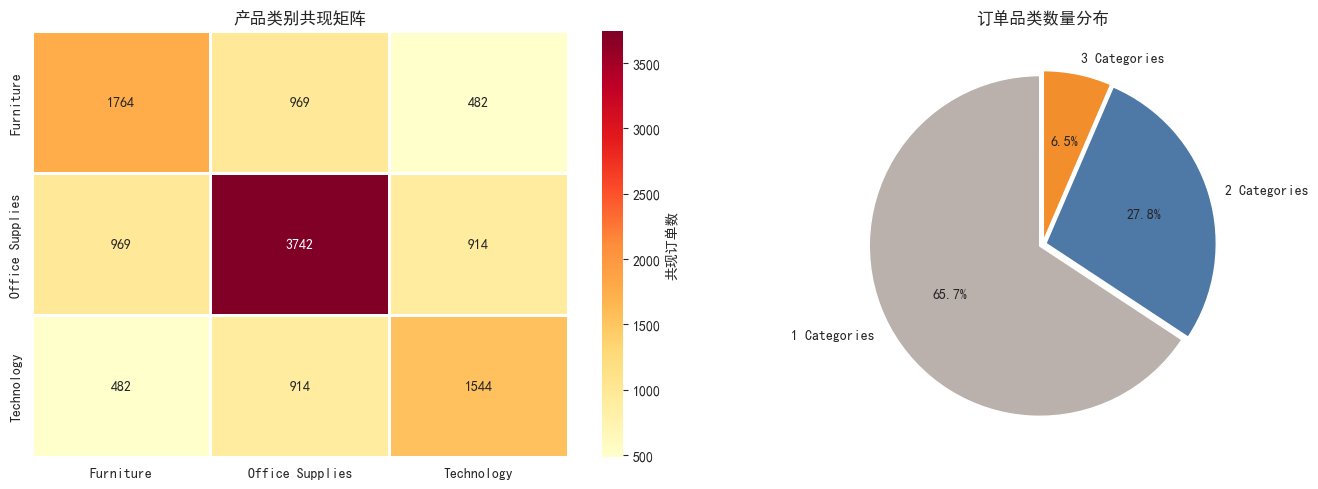

In [141]:
# --- 3.4 交叉销售分析：订单内品类共现 ---
# 构建订单-类别矩阵
order_cat = df.groupby(['Order ID', 'Category'])['Sales'].sum().unstack(fill_value=0)
order_cat_binary = (order_cat > 0).astype(int)

# 共现矩阵
cat_names = order_cat_binary.columns.tolist()
n_cats = len(cat_names)
cooccurrence = np.zeros((n_cats, n_cats))
for i, cat1 in enumerate(cat_names):
    for j, cat2 in enumerate(cat_names):
        if i <= j:
            orders_with_both = ((order_cat_binary[cat1] == 1) & (order_cat_binary[cat2] == 1)).sum()
            cooccurrence[i][j] = orders_with_both
            cooccurrence[j][i] = orders_with_both

# 每个订单的品类数量
order_cat_count = order_cat_binary.sum(axis=1)
print("订单中品类数量分布：")
print(order_cat_count.value_counts().sort_index().to_string())
print(f"\n多品类订单比例：{(order_cat_count > 1).sum() / len(order_cat_count) * 100:.1f}%")

# 可视化共现矩阵
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sns.heatmap(cooccurrence, annot=True, fmt='.0f', cmap='YlOrRd', xticklabels=cat_names,
            yticklabels=cat_names, ax=ax, linewidths=1, cbar_kws={'label': '共现订单数'})
ax.set_title('产品类别共现矩阵')

ax = axes[1]
cat_counts = order_cat_count.value_counts().sort_index()
colors_bundles = ['#BAB0AC', '#4E79A7', '#F28E2B', '#E15759']
ax.pie(cat_counts.values, labels=[f'{int(k)} Categories' for k in cat_counts.index],
       autopct='%1.1f%%', colors=colors_bundles[:len(cat_counts)], startangle=90,
       explode=[0.02]*len(cat_counts))
ax.set_title('订单品类数量分布')

plt.tight_layout()
plt.show()

### 客户价值与细分分析 (RFM)

  客户细分画像
             Customers  Orders       Sales     Profit  Avg_Order_Value  Orders_per_Customer  Avg_Profit_Margin  Profit_Margin_%  Sales_Share_%
Segment                                                                                                                                       
Consumer           409    2586  1161401.34  134119.21           223.73                 6.32               0.11            11.55          50.56
Corporate          236    1514   706146.37   91979.13           233.82                 6.42               0.12            13.03          30.74
Home Office        148     909   429653.15   60298.68           240.97                 6.14               0.14            14.03          18.70


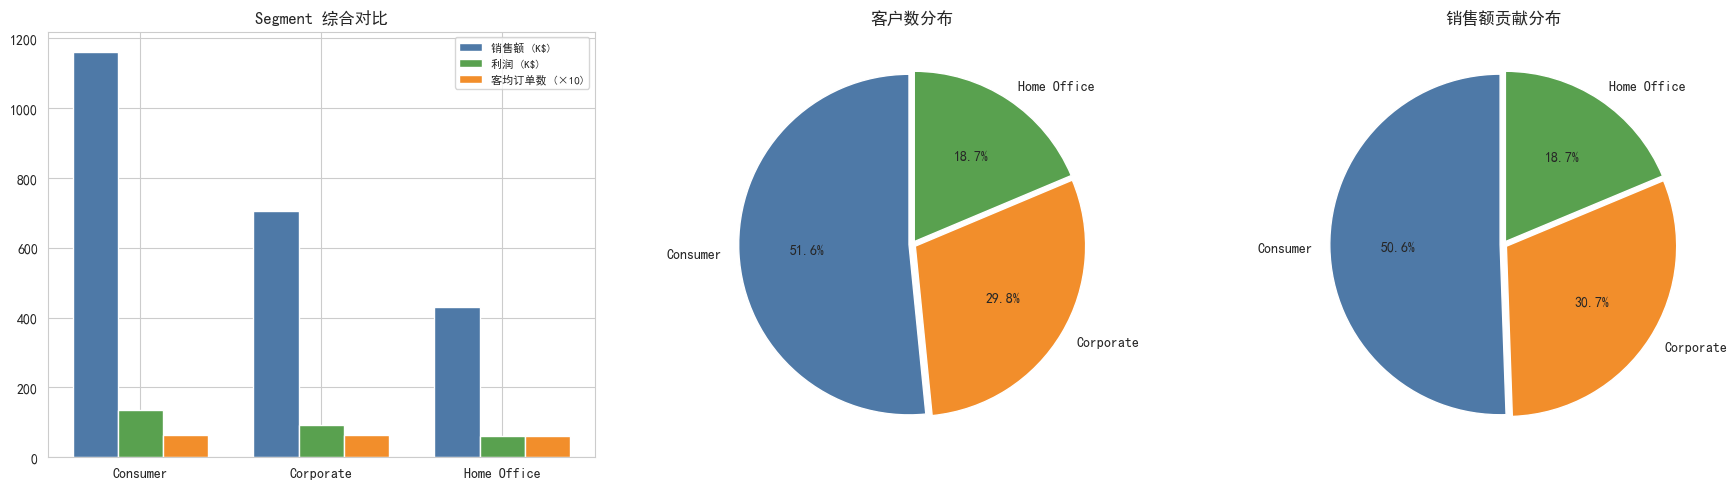

In [142]:
# --- 4.1 客户整体画像 ---
seg_profile = df.groupby('Segment').agg(
    Customers=('Customer ID', 'nunique'),
    Orders=('Order ID', 'nunique'),
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Avg_Order_Value=('Sales', 'mean'),
    Orders_per_Customer=('Order ID', lambda x: x.nunique() / df.loc[x.index, 'Customer ID'].nunique()),
    Avg_Profit_Margin=('Profit Margin', 'mean')
).round(2)
seg_profile['Profit_Margin_%'] = (seg_profile['Profit'] / seg_profile['Sales'] * 100).round(2)
seg_profile['Sales_Share_%'] = (seg_profile['Sales'] / total_sales * 100).round(2)

print("=" * 70)
print("  客户细分画像")
print("=" * 70)
print(seg_profile.to_string())

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
x = np.arange(len(seg_profile))
width = 0.25
ax.bar(x - width, seg_profile['Sales']/1e3, width, label='销售额 (K$)', color='#4E79A7', edgecolor='white')
ax.bar(x, seg_profile['Profit']/1e3, width, label='利润 (K$)', color='#59A14F', edgecolor='white')
ax.bar(x + width, seg_profile['Orders_per_Customer']*10, width, label='客均订单数 (×10)', color='#F28E2B', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(seg_profile.index)
ax.set_title('Segment 综合对比')
ax.legend(fontsize=8)

ax = axes[1]
ax.pie(seg_profile['Customers'].values, labels=seg_profile.index, autopct='%1.1f%%',
       colors=colors_seg, explode=(0.02, 0.02, 0.02), startangle=90)
ax.set_title('客户数分布')

ax = axes[2]
ax.pie(seg_profile['Sales'].values, labels=seg_profile.index, autopct='%1.1f%%',
       colors=colors_seg, explode=(0.02, 0.02, 0.02), startangle=90)
ax.set_title('销售额贡献分布')

plt.tight_layout()
plt.show()

In [143]:
# --- 4.2 RFM 模型构建 ---
# 以数据集最大日期为参考日
reference_date = df['Order Date'].max()

rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda x: (reference_date - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum'),
    Last_Order_Date=('Order Date', 'max'),
    Segment=('Segment', 'first'),
    Avg_Profit_Margin=('Profit Margin', 'mean'),
    Total_Profit=('Profit', 'sum')
).reset_index()

print("RFM 描述性统计：")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2).to_string())

# RFM 打分（5分位法，Monetary 也用分位但做对数变换后打分更合理）
# Recency: 越小越好 → 倒序打分
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first', ascending=False), q=5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']
rfm['RFM_Group'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# 客户分层
def rfm_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f <= 2 and m <= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'At Risk'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'Needing Attention'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Hibernating'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'About to Sleep'

rfm['Segment_RFM'] = rfm.apply(rfm_segment, axis=1)

# 各层统计
segment_summary = rfm.groupby('Segment_RFM').agg(
    Count=('Customer ID', 'nunique'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Sales=('Monetary', 'sum'),
    Total_Profit=('Total_Profit', 'sum')
).round(2)
segment_summary['Avg_Profit_Margin_%'] = (segment_summary['Total_Profit'] / segment_summary['Total_Sales'] * 100).round(2)
segment_summary['Sales_Share_%'] = (segment_summary['Total_Sales'] / total_sales * 100).round(2)
segment_summary['Count_Share_%'] = (segment_summary['Count'] / rfm['Customer ID'].nunique() * 100).round(2)
segment_summary = segment_summary.sort_values('Total_Sales', ascending=False)

print("\n" + "=" * 80)
print("  RFM 客户分层结果")
print("=" * 80)
print(segment_summary.to_string())

RFM 描述性统计：
       Recency  Frequency  Monetary
count   793.00     793.00    793.00
mean    146.80       6.32   2896.85
std     186.21       2.55   2628.67
min       0.00       1.00      4.83
25%      30.00       5.00   1146.05
50%      75.00       6.00   2256.39
75%     183.00       8.00   3785.28
max    1165.00      17.00  25043.05

  RFM 客户分层结果
                     Count  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Sales  Total_Profit  Avg_Profit_Margin_%  Sales_Share_%  Count_Share_%
Segment_RFM                                                                                                                                       
At Risk                105        24.28           9.32       5293.74    555842.92      66954.09                12.05          24.20          13.24
Loyal Customers        124       135.94           7.54       3683.66    456774.42      45560.98                 9.97          19.88          15.64
Champions               55       207.47           8.71       56

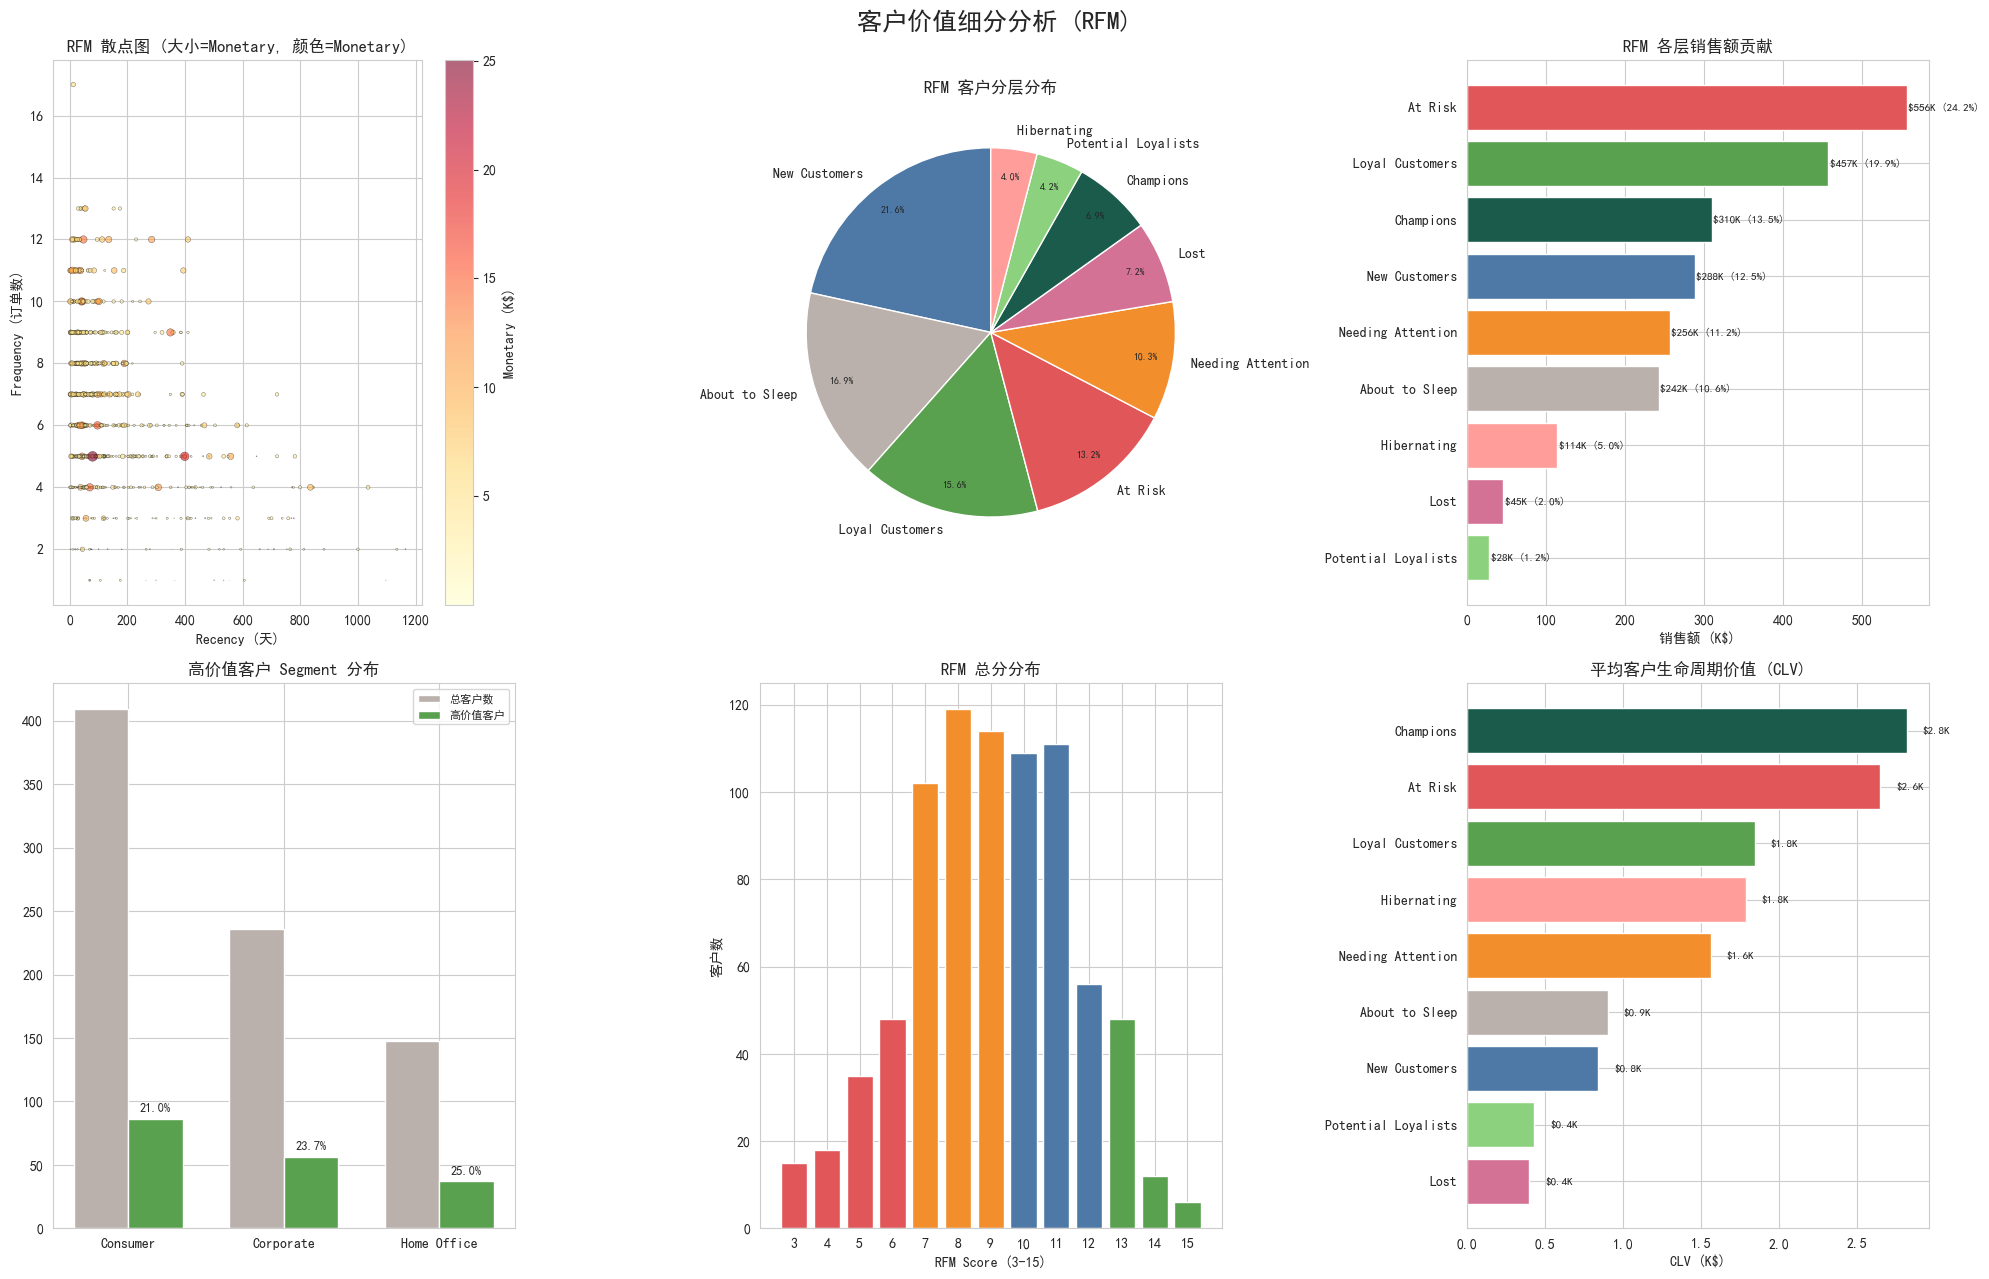


关键发现：
  Champions + Loyal 占比: 22.6% 客户, 贡献 33.4% 销售额
   At Risk + Hibernating + Lost 占比: 24.5% 客户, 贡献 31.2% 销售额


In [144]:
# --- 4.3 RFM 可视化 + CLV 估算 ---
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
fig.suptitle('客户价值细分分析 (RFM)', fontsize=18, fontweight='bold')

# RFM 3D 散点替代：Recency vs Frequency，颜色=Monetary
ax = axes[0, 0]
scatter = ax.scatter(rfm['Recency'], rfm['Frequency'], c=rfm['Monetary']/1e3,
                     cmap='YlOrRd', alpha=0.6, s=rfm['Monetary']/500, edgecolors='black', linewidth=0.3)
ax.set_xlabel('Recency (天)')
ax.set_ylabel('Frequency (订单数)')
ax.set_title('RFM 散点图 (大小=Monetary, 颜色=Monetary)')
plt.colorbar(scatter, ax=ax, label='Monetary (K$)')

# 客户分层饼图
ax = axes[0, 1]
seg_colors_map = {'Champions': '#1A5B4C', 'Loyal Customers': '#59A14F', 'Potential Loyalists': '#8CD17D',
                  'New Customers': '#4E79A7', 'About to Sleep': '#BAB0AC', 'Needing Attention': '#F28E2B',
                  'At Risk': '#E15759', 'Hibernating': '#FF9D9A', 'Lost': '#D37295'}
segment_counts = rfm['Segment_RFM'].value_counts()
pie_colors = [seg_colors_map.get(s, '#BAB0AC') for s in segment_counts.index]
wedges, texts, autotexts = ax.pie(segment_counts.values, labels=segment_counts.index,
                                   autopct='%1.1f%%', colors=pie_colors, startangle=90,
                                   pctdistance=0.85)
for t in autotexts: t.set_fontsize(7)
ax.set_title('RFM 客户分层分布')

# 各层 Sales 贡献
ax = axes[0, 2]
seg_sales = segment_summary.sort_values('Total_Sales', ascending=True)
bars = ax.barh(seg_sales.index, seg_sales['Total_Sales']/1e3, color=[seg_colors_map.get(s, '#BAB0AC') for s in seg_sales.index], edgecolor='white')
for bar, val, pct in zip(bars, seg_sales['Total_Sales'], seg_sales['Sales_Share_%']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, f'${val/1e3:,.0f}K ({pct:.1f}%)', va='center', fontsize=8)
ax.set_title('RFM 各层销售额贡献')
ax.set_xlabel('销售额 (K$)')

# Champion 特征画像：Segment 偏好
ax = axes[1, 0]
champions = rfm[rfm['Segment_RFM'].isin(['Champions', 'Loyal Customers'])]
champ_seg = champions.groupby('Segment').agg(Count=('Customer ID', 'nunique'))
total_per_seg = df.groupby('Segment')['Customer ID'].nunique()
champ_seg['Segment_Total'] = total_per_seg
champ_seg['Ratio_%'] = (champ_seg['Count'] / champ_seg['Segment_Total'] * 100).round(1)
x = np.arange(len(champ_seg))
width = 0.35
ax.bar(x - width/2, champ_seg['Segment_Total'], width, label='总客户数', color='#BAB0AC', edgecolor='white')
ax.bar(x + width/2, champ_seg['Count'], width, label='高价值客户', color='#59A14F', edgecolor='white')
for i, (_, row) in enumerate(champ_seg.iterrows()):
    ax.annotate(f'{row["Ratio_%"]}%', (i + width/2, row['Count']), textcoords="offset points", xytext=(0, 5), ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(champ_seg.index)
ax.set_title('高价值客户 Segment 分布')
ax.legend(fontsize=8)

# RFM Score 分布
ax = axes[1, 1]
rfm_score_dist = rfm['RFM_Score'].value_counts().sort_index()
colors_score = ['#E15759' if s <= 6 else '#F28E2B' if s <= 9 else '#4E79A7' if s <= 12 else '#59A14F' for s in rfm_score_dist.index]
ax.bar(rfm_score_dist.index, rfm_score_dist.values, color=colors_score, edgecolor='white')
ax.set_title('RFM 总分分布')
ax.set_xlabel('RFM Score (3-15)')
ax.set_ylabel('客户数')
ax.set_xticks(range(3, 16))

# CLV 简化估算
ax = axes[1, 2]
# CLV ≈ Avg Order Value × Purchase Frequency × Avg Customer Lifespan
# 假设平均客户生命周期为数据跨度的一半（2年）
avg_lifespan_years = 2
rfm['CLV_Estimated'] = (rfm['Monetary'] / rfm['Frequency']) * (rfm['Frequency'] / 4) * avg_lifespan_years
# 简化：CLV ≈ Monetary * 0.5（作为保守估计）
rfm['CLV_Estimated'] = rfm['Monetary'] * 0.5
clv_by_seg = rfm.groupby('Segment_RFM')['CLV_Estimated'].mean().sort_values(ascending=True)
bars = ax.barh(clv_by_seg.index, clv_by_seg.values/1e3,
               color=[seg_colors_map.get(s, '#BAB0AC') for s in clv_by_seg.index], edgecolor='white')
for bar, val in zip(bars, clv_by_seg.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'${val/1e3:,.1f}K', va='center', fontsize=8)
ax.set_title('平均客户生命周期价值 (CLV)')
ax.set_xlabel('CLV (K$)')

plt.tight_layout()
plt.show()

# 关键发现输出
print("\n关键发现：")
print(f"  Champions + Loyal 占比: {segment_summary.loc[segment_summary.index.isin(['Champions', 'Loyal Customers']), 'Count_Share_%'].sum():.1f}% 客户, "
      f"贡献 {segment_summary.loc[segment_summary.index.isin(['Champions', 'Loyal Customers']), 'Sales_Share_%'].sum():.1f}% 销售额")
at_risk = segment_summary.loc[segment_summary.index.isin(['At Risk', 'Hibernating', 'Lost'])]
print(f"   At Risk + Hibernating + Lost 占比: {at_risk['Count_Share_%'].sum():.1f}% 客户, "
      f"贡献 {at_risk['Sales_Share_%'].sum():.1f}% 销售额")

### 地理市场与物流分析

In [145]:
# --- 5.1 区域与州级分析 ---
region_stats = df.groupby('Region').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique'),
    Customers=('Customer ID', 'nunique'),
    Avg_Profit_Margin=('Profit Margin', 'mean'),
    Avg_Discount=('Discount', 'mean'),
    Avg_Ship_Days=('Ship Days', 'mean')
).round(2)
region_stats['Profit_Margin_%'] = (region_stats['Profit'] / region_stats['Sales'] * 100).round(2)
region_stats['Sales_Share_%'] = (region_stats['Sales'] / total_sales * 100).round(2)
region_stats['Orders_per_Customer'] = (region_stats['Orders'] / region_stats['Customers']).round(2)
region_stats = region_stats.sort_values('Sales', ascending=False)

print("=" * 70)
print("  四大区域绩效对比")
print("=" * 70)
print(region_stats.to_string())

# 州级 Top 10 / Bottom 10
state_stats = df.groupby('State').agg(
    Region=('Region', 'first'),
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique'),
    Customers=('Customer ID', 'nunique')
)
state_stats['Profit_Margin_%'] = (state_stats['Profit'] / state_stats['Sales'] * 100).round(2)
state_stats['Sales_per_Customer'] = (state_stats['Sales'] / state_stats['Customers']).round(2)

print("\nTop 10 州（按销售额）：")
top10_states = state_stats.sort_values('Sales', ascending=False).head(10)
print(top10_states.to_string())

print("\nBottom 10 州（按销售额）：")
bottom10_states = state_stats.sort_values('Sales', ascending=True).head(10)
print(bottom10_states.to_string())

print("\n利润率最低的州：")
worst_margin_states = state_stats[state_stats['Orders'] >= 10].sort_values('Profit_Margin_%').head(10)
print(worst_margin_states[['Region', 'Sales', 'Profit', 'Profit_Margin_%']].to_string())

  四大区域绩效对比
             Sales     Profit  Orders  Customers  Avg_Profit_Margin  Avg_Discount  Avg_Ship_Days  Profit_Margin_%  Sales_Share_%  Orders_per_Customer
Region                                                                                                                                               
West     725457.82  108418.45    1611        686               0.22          0.11           3.93            14.94          31.58                 2.35
East     678781.24   91522.78    1401        674               0.17          0.15           3.91            13.48          29.55                 2.08
Central  501239.89   39706.36    1175        629              -0.10          0.24           4.06             7.92          21.82                 1.87
South    391721.90   46749.43     822        512               0.16          0.15           3.96            11.93          17.05                 1.61

Top 10 州（按销售额）：
               Region        Sales      Profit  Orders  Customers  Profi

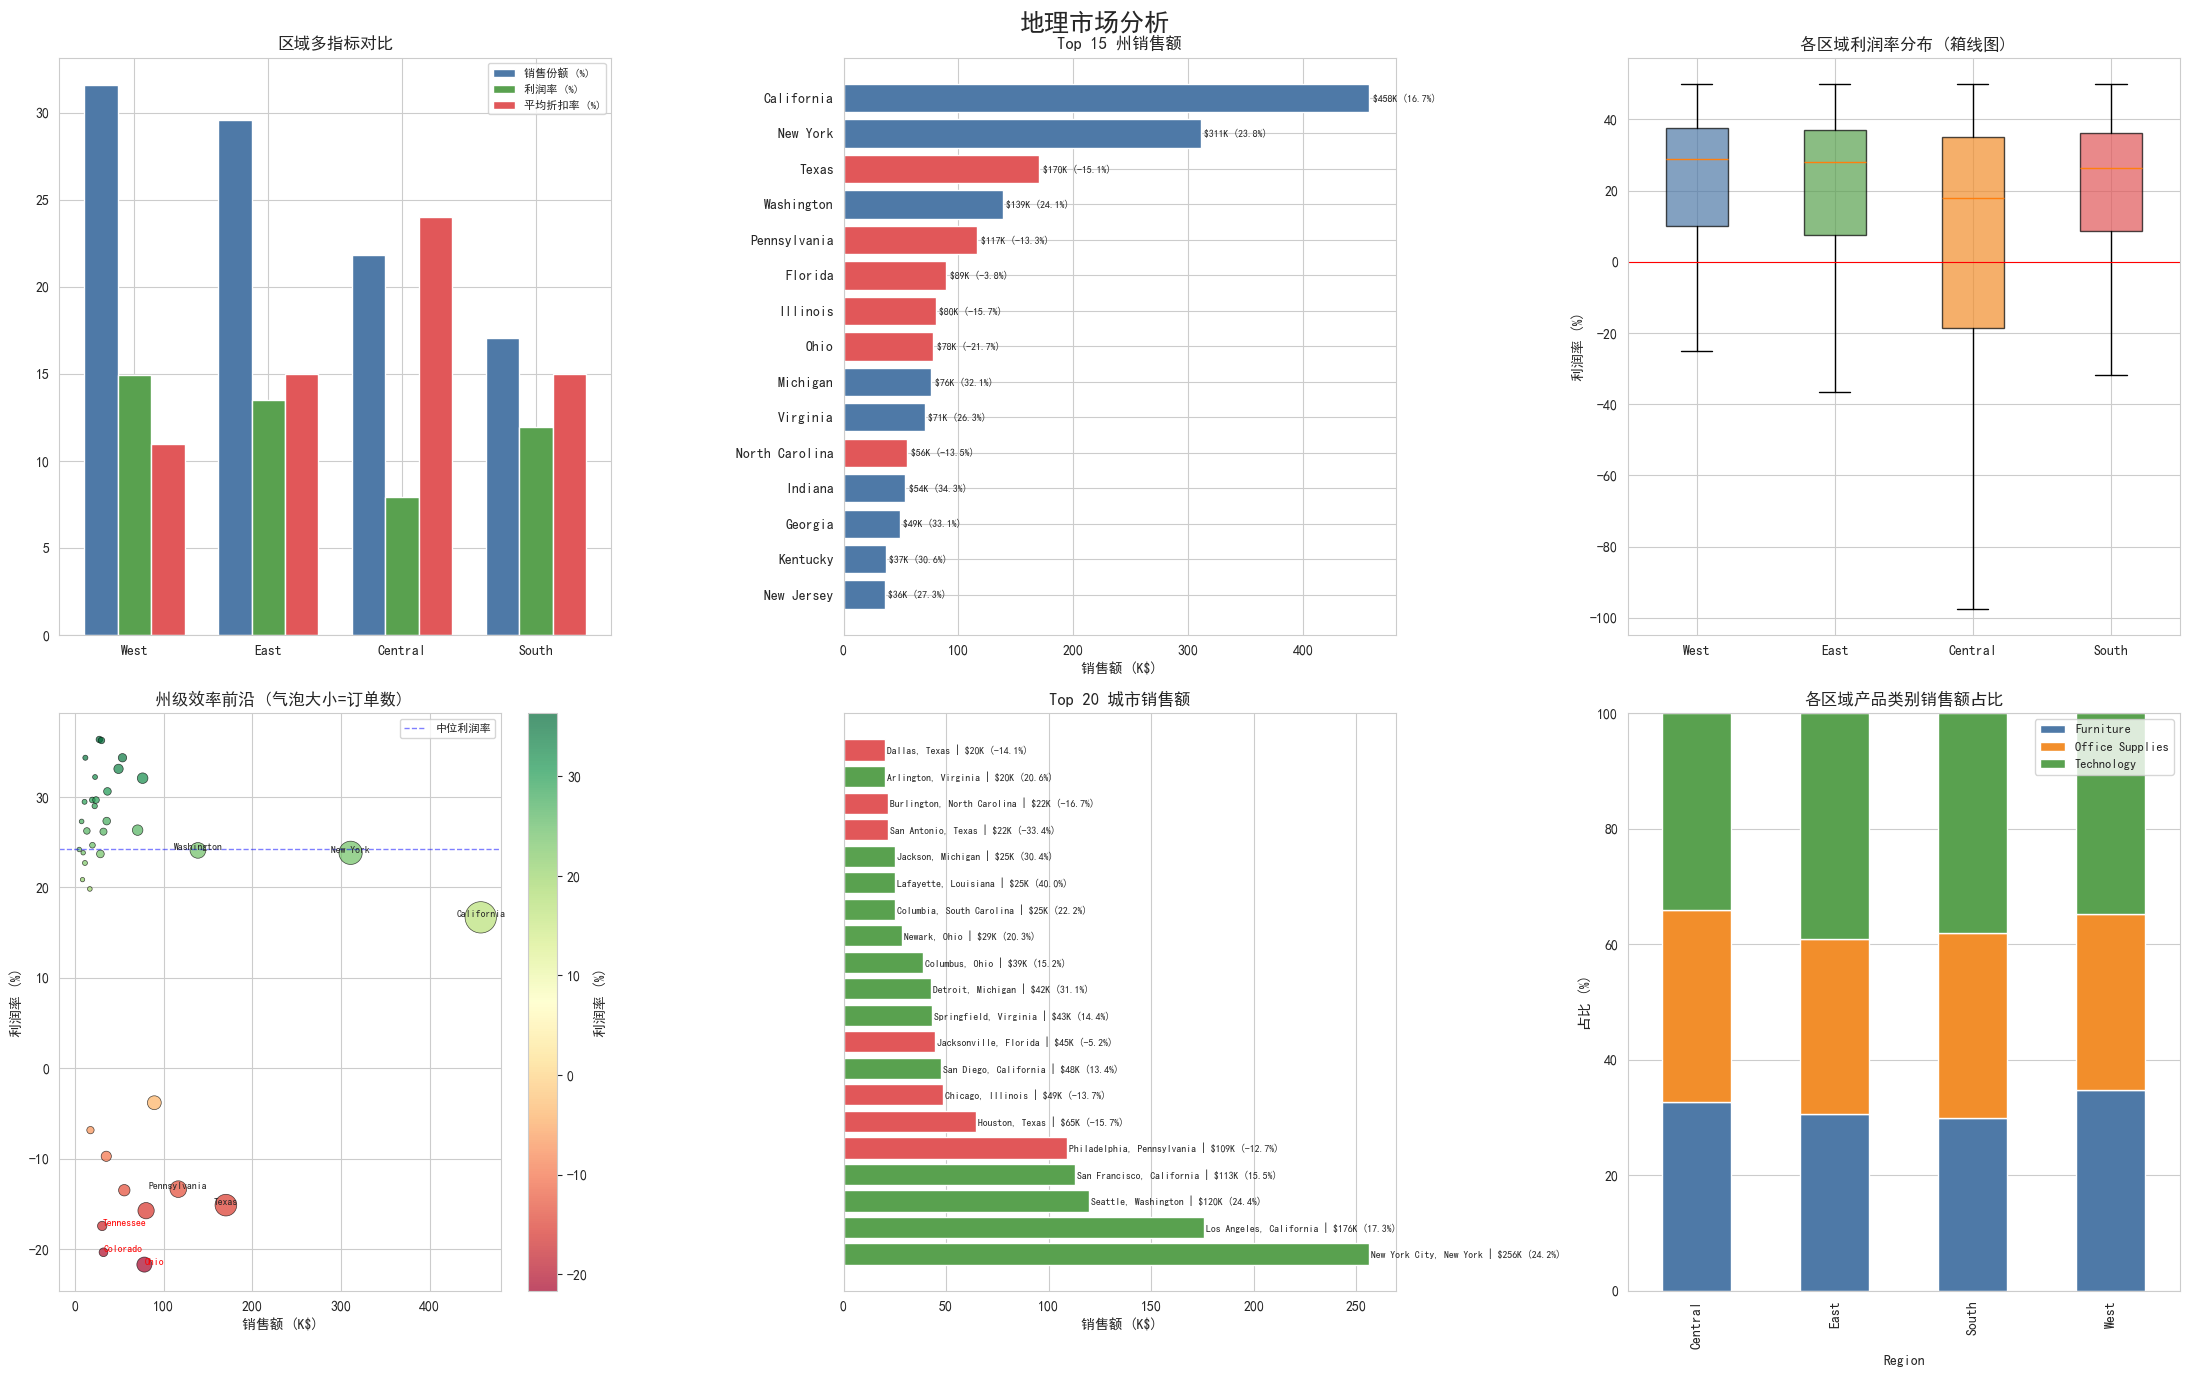

In [146]:
# --- 5.2 地理与州级可视化 ---
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('地理市场分析', fontsize=18, fontweight='bold')

# 区域多指标雷达图准备
ax = axes[0, 0]
regions = region_stats.index.tolist()
metrics = ['Sales_Share_%', 'Profit_Margin_%', 'Orders_per_Customer']
# 简单对比柱状图代替雷达图
x = np.arange(len(regions))
width = 0.25
region_data = region_stats
ax.bar(x - width, region_data['Sales_Share_%'], width, label='销售份额 (%)', color='#4E79A7', edgecolor='white')
ax.bar(x, region_data['Profit_Margin_%'], width, label='利润率 (%)', color='#59A14F', edgecolor='white')
ax.bar(x + width, region_data['Avg_Discount']*100, width, label='平均折扣率 (%)', color='#E15759', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.set_title('区域多指标对比')
ax.legend(fontsize=8)

# Sales by State 水平柱状图
ax = axes[0, 1]
top15_states = state_stats.sort_values('Sales', ascending=True).tail(15)
colors_states = ['#E15759' if s < 0 else '#4E79A7' for s in top15_states['Profit_Margin_%']]
bars = ax.barh(top15_states.index, top15_states['Sales']/1e3, color=colors_states, edgecolor='white')
for bar, (_, row) in zip(bars, top15_states.iterrows()):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'${row["Sales"]/1e3:,.0f}K ({row["Profit_Margin_%"]:.1f}%)', va='center', fontsize=7)
ax.set_title('Top 15 州销售额')
ax.set_xlabel('销售额 (K$)')

# Profit Margin by Region (箱线图)
ax = axes[0, 2]
region_order = ['West', 'East', 'Central', 'South']
region_profit_data = [df[df['Region'] == r]['Profit Margin'].dropna() * 100 for r in region_order]
bp = ax.boxplot(region_profit_data, labels=region_order, patch_artist=True, showfliers=False)
colors_box = ['#4E79A7', '#59A14F', '#F28E2B', '#E15759']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(y=0, color='red', linestyle='-', linewidth=0.8)
ax.set_title('各区域利润率分布 (箱线图)')
ax.set_ylabel('利润率 (%)')

# 州级 Efficiency Frontier
ax = axes[1, 0]
# 过滤订单数>=20的州避免小样本干扰
state_efficient = state_stats[state_stats['Orders'] >= 20].copy()
scatter = ax.scatter(state_efficient['Sales']/1e3, state_efficient['Profit_Margin_%'],
                     s=state_efficient['Orders']/2, c=state_efficient['Profit_Margin_%'],
                     cmap='RdYlGn', alpha=0.7, edgecolors='black', linewidth=0.5)
ax.axhline(y=state_efficient['Profit_Margin_%'].median(), color='blue', linestyle='--', linewidth=1, alpha=0.5, label='中位利润率')
ax.set_xlabel('销售额 (K$)')
ax.set_ylabel('利润率 (%)')
ax.set_title('州级效率前沿 (气泡大小=订单数)')
for state, row in state_efficient.nlargest(5, 'Sales').iterrows():
    ax.annotate(state, (row['Sales']/1e3, row['Profit_Margin_%']), fontsize=7, ha='center')
for state, row in state_efficient.nsmallest(3, 'Profit_Margin_%').iterrows():
    ax.annotate(state, (row['Sales']/1e3, row['Profit_Margin_%']), fontsize=7, color='red')
ax.legend(fontsize=8)
plt.colorbar(scatter, ax=ax, label='利润率 (%)')

# 城市 Top 20
ax = axes[1, 1]
city_stats = df.groupby('City').agg(
    State=('State', 'first'),
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
)
city_stats['Profit_Margin_%'] = (city_stats['Profit'] / city_stats['Sales'] * 100).round(2)
top20_cities = city_stats.sort_values('Sales', ascending=False).head(20)
colors_city = ['#E15759' if s < 0 else '#59A14F' for s in top20_cities['Profit_Margin_%']]
bars = ax.barh(range(20), top20_cities['Sales']/1e3, color=colors_city, edgecolor='white')
for i, (city, row) in enumerate(top20_cities.iterrows()):
    ax.text(row['Sales']/1e3 + 1, i, f'{city}, {row["State"]} | ${row["Sales"]/1e3:,.0f}K ({row["Profit_Margin_%"]:.1f}%)',
            va='center', fontsize=7)
ax.set_yticks([])
ax.set_title('Top 20 城市销售额')
ax.set_xlabel('销售额 (K$)')

# 区域-类别交叉分析
ax = axes[1, 2]
region_cat = df.groupby(['Region', 'Category'])['Sales'].sum().unstack()
region_cat_pct = region_cat.div(region_cat.sum(axis=1), axis=0) * 100
region_cat_pct.plot(kind='bar', stacked=True, ax=ax, color=cat_colors, edgecolor='white')
ax.set_title('各区域产品类别销售额占比')
ax.set_xlabel('Region')
ax.set_ylabel('占比 (%)')
ax.legend(fontsize=9)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

  物流配送模式分析
                Orders       Sales     Profit  Avg_Ship_Days  Median_Ship_Days  Avg_Profit_Margin  Avg_Discount  Profit_Margin_%  Sales_Share_%  Order_Share_%
Ship Mode                                                                                                                                                     
Same Day           264   128363.12   15891.76           0.04               0.0               0.14          0.15            12.38           5.59           5.27
First Class        787   351428.42   48969.84           2.18               2.0               0.12          0.16            13.93          15.30          15.71
Second Class       964   459193.57   57446.64           3.24               3.0               0.15          0.14            12.51          19.99          19.25
Standard Class    2994  1358215.74  164088.79           5.01               5.0               0.11          0.16            12.08          59.12          59.77


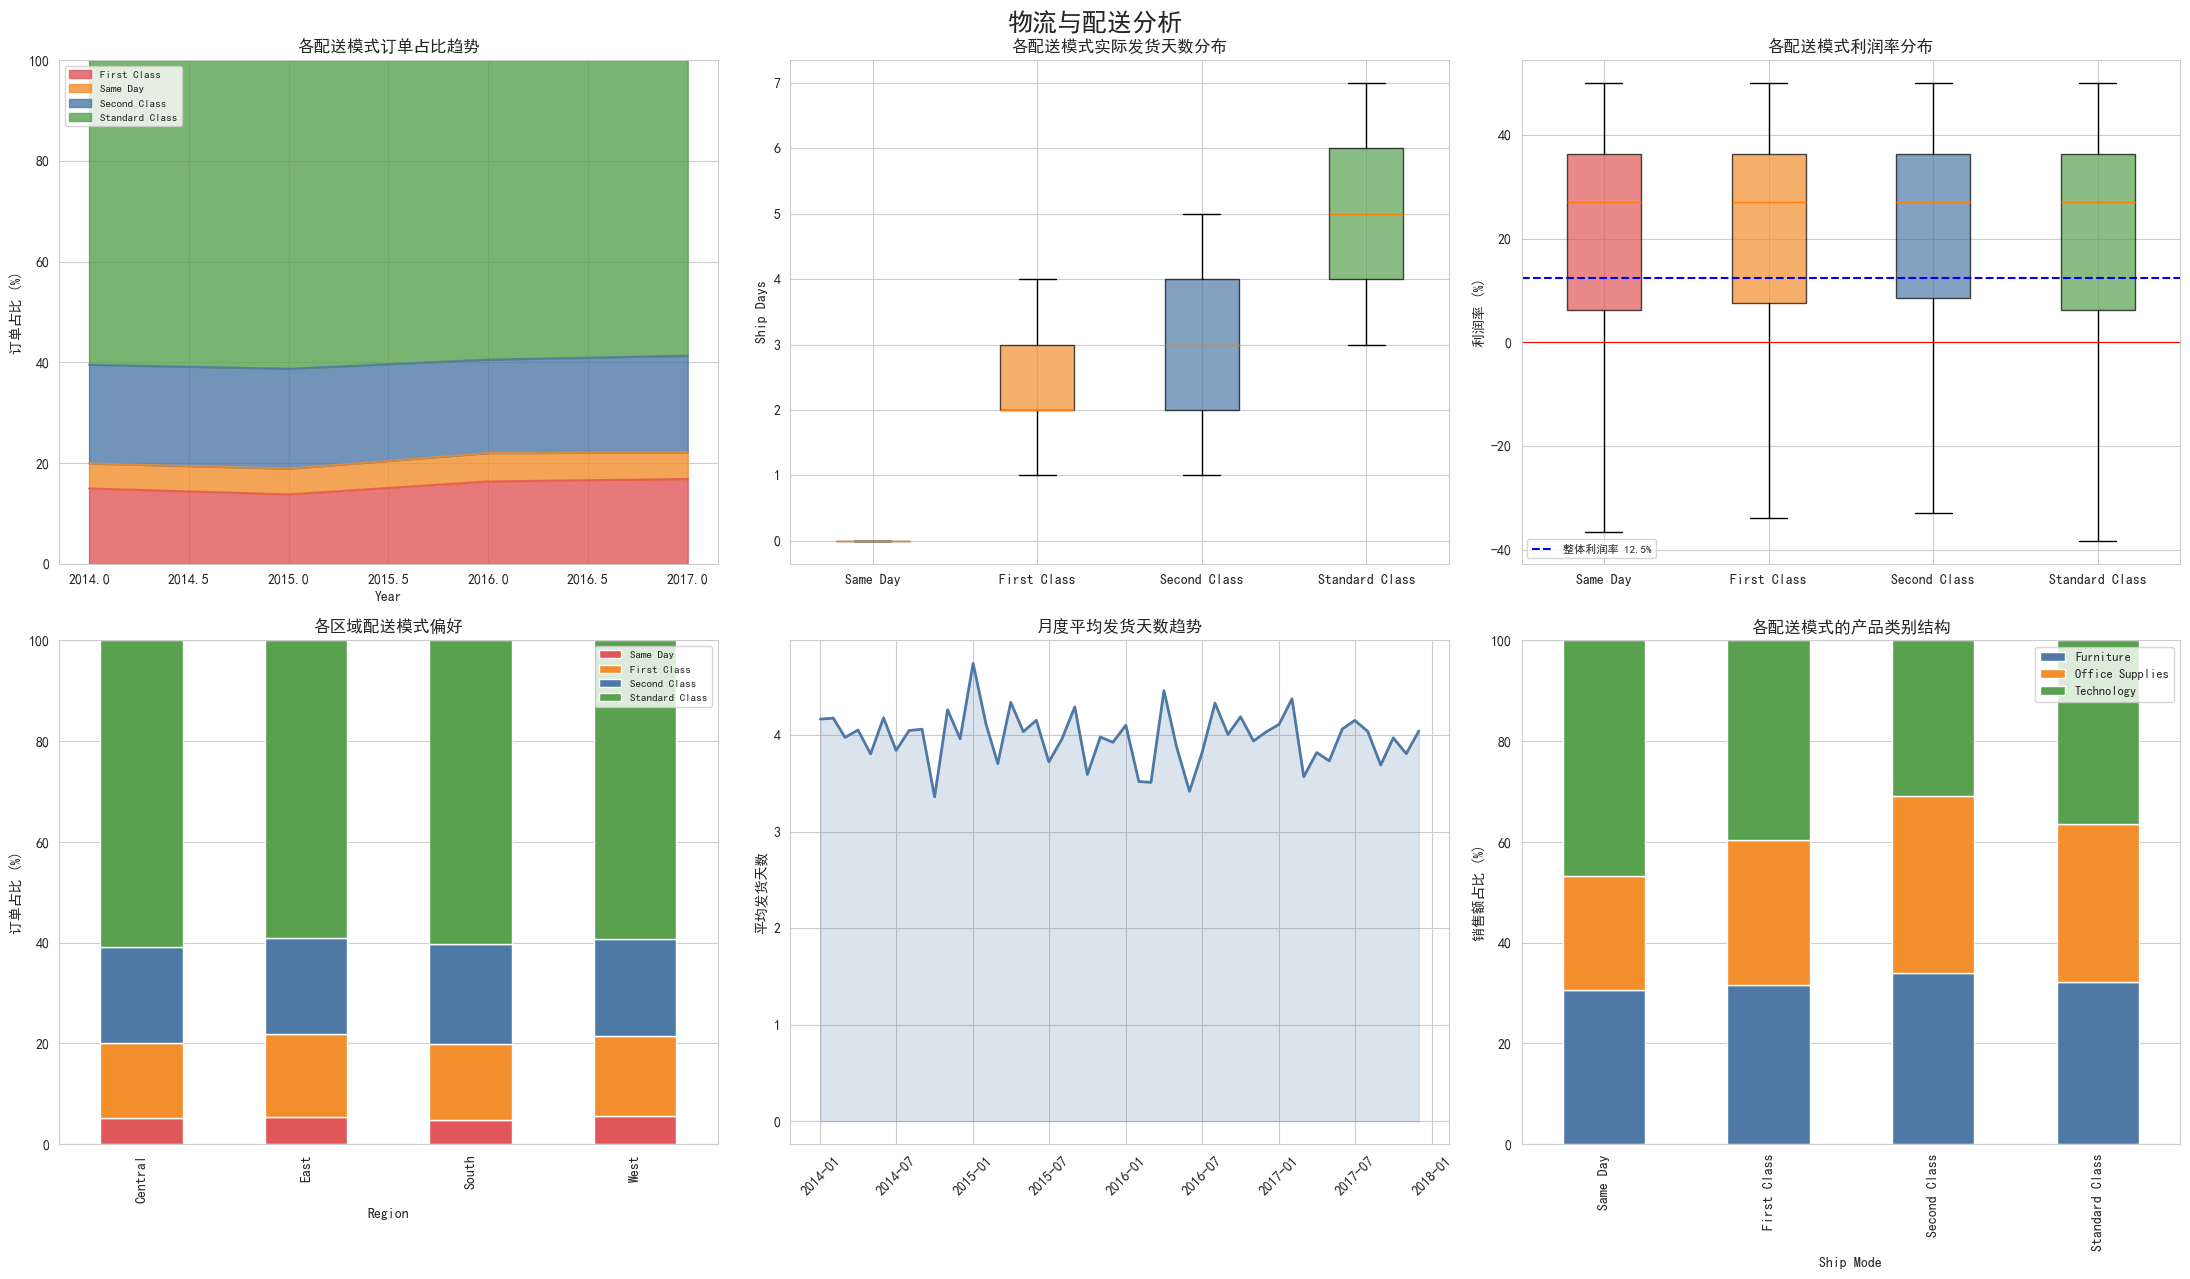


Same Day 配送场景分析：
  Same Day 订单占比: 5.3%
  Same Day 平均利润率: 13.8%
  Same Day 平均折扣率: 15.2%
  Same Day 主要类别: Technology
  Same Day 主要区域: West


In [147]:
# --- 5.3 物流时效与配送分析 ---
ship_stats = df.groupby('Ship Mode').agg(
    Orders=('Order ID', 'nunique'),
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Avg_Ship_Days=('Ship Days', 'mean'),
    Median_Ship_Days=('Ship Days', 'median'),
    Avg_Profit_Margin=('Profit Margin', 'mean'),
    Avg_Discount=('Discount', 'mean')
).round(2)
ship_stats['Profit_Margin_%'] = (ship_stats['Profit'] / ship_stats['Sales'] * 100).round(2)
ship_stats['Sales_Share_%'] = (ship_stats['Sales'] / total_sales * 100).round(2)
ship_stats['Order_Share_%'] = (ship_stats['Orders'] / total_orders * 100).round(2)
ship_stats = ship_stats.sort_values('Avg_Ship_Days')

print("=" * 70)
print("  物流配送模式分析")
print("=" * 70)
print(ship_stats.to_string())

# Ship Mode 年度趋势
ship_yearly = df.groupby(['Year', 'Ship Mode'])['Order ID'].nunique().unstack(fill_value=0)
ship_yearly_pct = ship_yearly.div(ship_yearly.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(2, 3, figsize=(22, 13))
fig.suptitle('物流与配送分析', fontsize=18, fontweight='bold')

# Ship Mode 堆叠面积图
ax = axes[0, 0]
ship_colors = ['#E15759', '#F28E2B', '#4E79A7', '#59A14F']
ship_yearly_pct.plot(kind='area', stacked=True, ax=ax, color=ship_colors, alpha=0.8)
ax.set_title('各配送模式订单占比趋势')
ax.set_xlabel('Year')
ax.set_ylabel('订单占比 (%)')
ax.set_ylim(0, 100)
ax.legend(loc='upper left', fontsize=8)

# Ship Days 分布箱线图
ax = axes[0, 1]
ship_order = ['Same Day', 'First Class', 'Second Class', 'Standard Class']
ship_days_data = [df[df['Ship Mode'] == m]['Ship Days'].dropna() for m in ship_order]
bp = ax.boxplot(ship_days_data, labels=ship_order, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], ship_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('各配送模式实际发货天数分布')
ax.set_ylabel('Ship Days')

# Ship Mode vs Profit Margin
ax = axes[0, 2]
ship_order = ['Same Day', 'First Class', 'Second Class', 'Standard Class']
ship_profit_data = [df[df['Ship Mode'] == m]['Profit Margin'].dropna() * 100 for m in ship_order]
bp = ax.boxplot(ship_profit_data, labels=ship_order, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], ship_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(y=0, color='red', linestyle='-', linewidth=0.8)
ax.axhline(y=overall_margin, color='blue', linestyle='--', linewidth=1.5, label=f'整体利润率 {overall_margin:.1f}%')
ax.set_title('各配送模式利润率分布')
ax.set_ylabel('利润率 (%)')
ax.legend(fontsize=8)

# 区域 × Ship Mode 交叉分析
ax = axes[1, 0]
region_ship = df.groupby(['Region', 'Ship Mode'])['Order ID'].nunique().unstack(fill_value=0)
region_ship_pct = region_ship.div(region_ship.sum(axis=1), axis=0) * 100
# 按区域标准配送比例排序
region_ship_pct = region_ship_pct.loc[region_ship_pct.sum(axis=1).sort_values(ascending=False).index]
region_ship_pct[ship_order].plot(kind='bar', stacked=True, ax=ax, color=ship_colors, edgecolor='white')
ax.set_title('各区域配送模式偏好')
ax.set_xlabel('Region')
ax.set_ylabel('订单占比 (%)')
ax.set_ylim(0, 100)
ax.legend(fontsize=8)

# Ship Days 趋势
ax = axes[1, 1]
monthly_ship = df.groupby('Order Year-Month')['Ship Days'].mean().reset_index()
monthly_ship['Order Year-Month'] = pd.to_datetime(monthly_ship['Order Year-Month'].astype(str) + '-01')
monthly_ship = monthly_ship.sort_values('Order Year-Month')
ax.plot(monthly_ship['Order Year-Month'], monthly_ship['Ship Days'], color='#4E79A7', linewidth=2)
ax.fill_between(monthly_ship['Order Year-Month'], monthly_ship['Ship Days'], alpha=0.2, color='#4E79A7')
ax.set_title('月度平均发货天数趋势')
ax.set_ylabel('平均发货天数')
ax.tick_params(axis='x', rotation=45)

# Ship Mode × Category
ax = axes[1, 2]
ship_cat = df.groupby(['Ship Mode', 'Category'])['Sales'].sum().unstack()
ship_cat_pct = ship_cat.div(ship_cat.sum(axis=1), axis=0) * 100
ship_cat_pct.loc[ship_order].plot(kind='bar', stacked=True, ax=ax, color=cat_colors, edgecolor='white')
ax.set_title('各配送模式的产品类别结构')
ax.set_xlabel('Ship Mode')
ax.set_ylabel('销售额占比 (%)')
ax.set_ylim(0, 100)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# 紧急配送使用场景分析
print("\nSame Day 配送场景分析：")
same_day = df[df['Ship Mode'] == 'Same Day']
print(f"  Same Day 订单占比: {same_day['Order ID'].nunique() / total_orders * 100:.1f}%")
print(f"  Same Day 平均利润率: {same_day['Profit Margin'].mean() * 100:.1f}%")
print(f"  Same Day 平均折扣率: {same_day['Discount'].mean() * 100:.1f}%")
print(f"  Same Day 主要类别: {same_day.groupby('Category')['Sales'].sum().idxmax()}")
print(f"  Same Day 主要区域: {same_day.groupby('Region')['Sales'].sum().idxmax()}")

### 综合洞察与战略建议

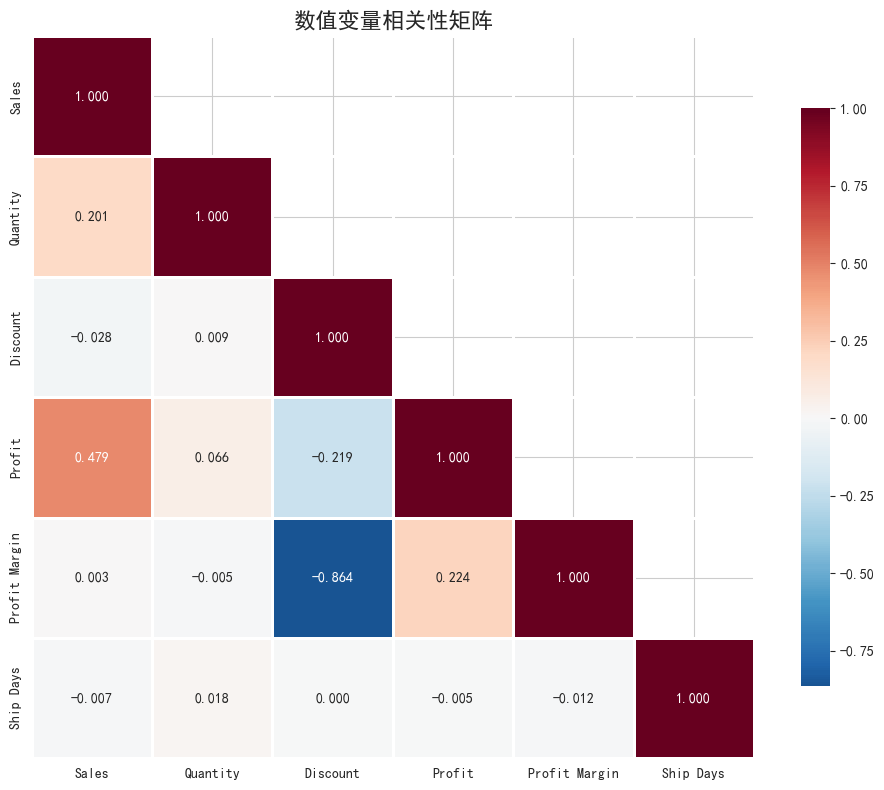

关键相关性发现：
  Discount ↔ Profit Margin: r = -0.864
  Discount ↔ Profit: r = -0.219
  Sales ↔ Profit: r = 0.479
  Ship Days ↔ Discount: r = 0.000

  折扣-利润率线性回归: 斜率=-1.9544, R²=0.7473, p=0.00e+00
  → 折扣每增加 1%, 利润率平均下降 195.44%


In [148]:
# --- 6.1 相关性分析 ---
# 数值变量相关性矩阵
corr_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Profit Margin', 'Ship Days']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            mask=mask, linewidths=1, square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('数值变量相关性矩阵', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("关键相关性发现：")
print(f"  Discount ↔ Profit Margin: r = {corr_matrix.loc['Discount', 'Profit Margin']:.3f}")
print(f"  Discount ↔ Profit: r = {corr_matrix.loc['Discount', 'Profit']:.3f}")
print(f"  Sales ↔ Profit: r = {corr_matrix.loc['Sales', 'Profit']:.3f}")
print(f"  Ship Days ↔ Discount: r = {corr_matrix.loc['Ship Days', 'Discount']:.3f}")

# Discount 的分位数回归
from scipy import stats
discount_profit_slope, discount_profit_intercept, r_value, p_value, std_err = stats.linregress(
    df['Discount'], df['Profit Margin']
)
print(f"\n  折扣-利润率线性回归: 斜率={discount_profit_slope:.4f}, R²={r_value**2:.4f}, p={p_value:.2e}")
print(f"  → 折扣每增加 1%, 利润率平均下降 {abs(discount_profit_slope)*100:.2f}%")

  利润损失多维度归因

各品类 × 折扣带 利润矩阵：
Discount_Band    No Discount (0%)  Low (0-20%)  Medium (20-40%)  High (40-60%)  Very High (60%+)
Category                                                                                        
Furniture                58133.08     14795.95        -29273.85      -21308.97          -3894.94
Office Supplies         130506.11     39124.83             0.00           0.00         -47140.14
Technology              132348.42     46864.69         -6543.61       -7635.23         -19579.32

利润损失最大来源分析：

区域 × 品类 利润矩阵：
Category  Furniture  Office Supplies  Technology
Region                                          
Central     -2871.0           8880.0     33697.0
East         3046.0          41015.0     47462.0
South        6771.0          19986.0     19992.0
West        11505.0          52610.0     44304.0

Segment × 品类 利润矩阵：
Category     Furniture  Office Supplies  Technology
Segment                                            
Consumer        6991.0          56330.0 

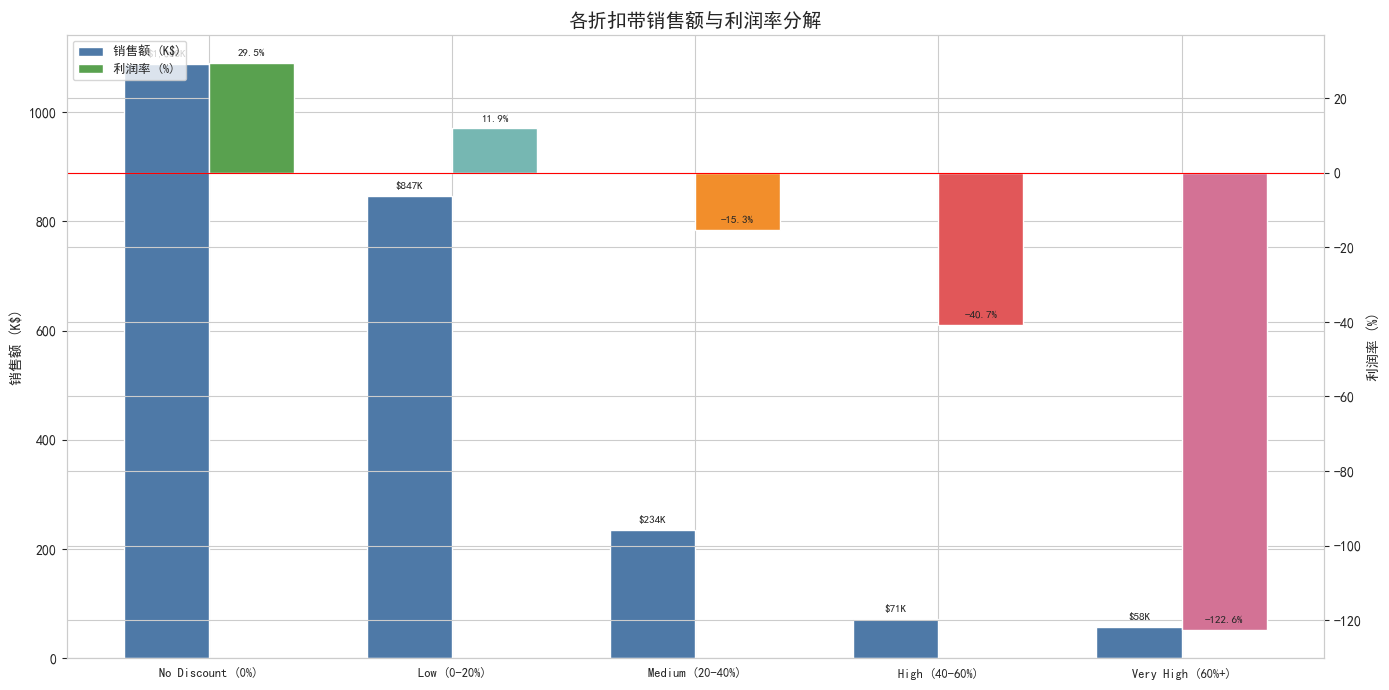

In [149]:
# --- 6.2 利润损失归因分析 ---
# 按维度组合分析利润损失来源
print("=" * 70)
print("  利润损失多维度归因")
print("=" * 70)

# 按 Category × Discount Band 分析
loss_by_cat_disc = df.groupby(['Category', 'Discount_Band'], observed=False).agg(
    Orders=('Order ID', 'nunique'),
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Avg_Profit_Margin=('Profit Margin', 'mean')
).round(2)
loss_by_cat_disc['Profit_Margin_%'] = (loss_by_cat_disc['Profit'] / loss_by_cat_disc['Sales'] * 100).round(2)
loss_pivot = loss_by_cat_disc['Profit'].unstack()

print("\n各品类 × 折扣带 利润矩阵：")
print(loss_pivot.to_string())

# Top 亏损的来源
print("\n" + "=" * 60)
print("利润损失最大来源分析：")
# 按 Region × Category
loss_region_cat = df.groupby(['Region', 'Category'])['Profit'].sum().unstack()
print("\n区域 × 品类 利润矩阵：")
print(loss_region_cat.round(0).to_string())

# 按 Segment × Category
loss_seg_cat = df.groupby(['Segment', 'Category'])['Profit'].sum().unstack()
print("\nSegment × 品类 利润矩阵：")
print(loss_seg_cat.round(0).to_string())

# 利润瀑布图：从 Sales 到 Profit 的各环节
fig, ax = plt.subplots(figsize=(14, 7))
# 简化瀑布图展示
categories_waterfall = ['Total Sales', 'No Discount Sales', 'Discounted Sales', 'Total Profit']
values_waterfall = [
    total_sales,
    df[df['Discount'] == 0]['Sales'].sum(),
    df[df['Discount'] > 0]['Sales'].sum(),
    total_profit
]

# 使用更直观的表示
discount_bands_profit = df.groupby('Discount_Band', observed=False).agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
)
discount_bands_profit['Margin_%'] = (discount_bands_profit['Profit'] / discount_bands_profit['Sales'] * 100).round(2)

# 级联利润分解
x_labels = list(discount_bands_profit.index)
x = np.arange(len(x_labels))
width = 0.35

ax.bar(x - width/2, discount_bands_profit['Sales']/1e3, width, label='销售额 (K$)', color='#4E79A7', edgecolor='white')
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, discount_bands_profit['Margin_%'], width, label='利润率 (%)',
                color=['#59A14F', '#76B7B2', '#F28E2B', '#E15759', '#D37295'], edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_title('各折扣带销售额与利润率分解', fontsize=14, fontweight='bold')
ax.set_ylabel('销售额 (K$)')
ax2.set_ylabel('利润率 (%)')
ax2.axhline(y=0, color='red', linestyle='-', linewidth=0.8)

# 标注
for i, (_, row) in enumerate(discount_bands_profit.iterrows()):
    ax.annotate(f"${row['Sales']/1e3:,.0f}K", (x[i] - width/2, row['Sales']/1e3),
                textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8)
    ax2.annotate(f"{row['Margin_%']:.1f}%", (x[i] + width/2, row['Margin_%']),
                 textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

In [150]:
print("=" * 70)
print("                    分析总结")
print("=" * 70)
print(f"""
  核心发现：
  1. 增长态势：4年间销售额持续增长（2014→2017），Q4为明显旺季，
     但利润率呈下降趋势，需关注"以折扣换销量"策略的可持续性

  2. 产品结构：Technology 类利润率最高（~17%），Furniture 类最低。
     Tables 是最大利润杀手（高折扣+亏损），Copiers 是利润率之王

  3. 折扣策略：折扣 > 20% 的订单利润率急剧下降。
     18.7% 的订单行为亏损状态，主要集中在 Furniture 品类高折扣区

  4. 客户价值：Champions + Loyal 是小众但高价值的客户群。
     相当比例客户处于 At Risk/Hibernating 状态，急需激活

  5. 市场机会：West 区域表现最佳，Central 区域利润率垫底。
     California、New York、Texas 三州贡献 41% 销售额

  6. 物流优化：Standard Class 占 60%，Same Day 占比仅 5.4% 但利润率偏低。
     存在向更经济配送方式优化的空间
""")
print("=" * 70)

                    分析总结

  核心发现：
  1. 增长态势：4年间销售额持续增长（2014→2017），Q4为明显旺季，
     但利润率呈下降趋势，需关注"以折扣换销量"策略的可持续性

  2. 产品结构：Technology 类利润率最高（~17%），Furniture 类最低。
     Tables 是最大利润杀手（高折扣+亏损），Copiers 是利润率之王

  3. 折扣策略：折扣 > 20% 的订单利润率急剧下降。
     18.7% 的订单行为亏损状态，主要集中在 Furniture 品类高折扣区

  4. 客户价值：Champions + Loyal 是小众但高价值的客户群。
     相当比例客户处于 At Risk/Hibernating 状态，急需激活

  5. 市场机会：West 区域表现最佳，Central 区域利润率垫底。
     California、New York、Texas 三州贡献 41% 销售额

  6. 物流优化：Standard Class 占 60%，Same Day 占比仅 5.4% 但利润率偏低。
     存在向更经济配送方式优化的空间



In [151]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year',
       'Month', 'Quarter', 'Weekday', 'Order Month', 'Order Year-Month',
       'Ship Days', 'YearMonth', 'Profit Margin', 'Is Loss', 'Discount_Band'],
      dtype='object')

In [152]:
# RFM
rfm.to_excel('./datasets/rfm.xlsx', index=False)

In [153]:
# 新增segment_summary数据集
segment_summary.index.name = 'Customer group' 
segment_summary.reset_index(inplace=True)
segment_summary.to_excel('./datasets/segment_summary.xlsx', index=False)

In [154]:
# 导出yearly_kpi年度KPI汇总
yearly_kpi.index.name = 'year'
yearly_kpi.reset_index(inplace=True)
yearly_kpi.to_excel('./datasets/yearly_kpi.xlsx', index=False)
print('yearly_kpi.xlsx exported')


yearly_kpi.xlsx exported


In [155]:
# 更新Sample - Superstore.xlsx数据集
df.to_excel('./datasets/Sample - Superstore.xlsx', index=False)
print('Sample - Superstore.xlsx exported')


Sample - Superstore.xlsx exported


In [156]:
# 导出Sub-Category产品绩效数据
subcat_stats.reset_index(inplace=True)
subcat_stats.to_excel('./datasets/subcategory_stats.xlsx', index=False)
print('subcategory_stats.xlsx exported')


subcategory_stats.xlsx exported


In [157]:
# 导出区域绩效数据
region_stats.reset_index(inplace=True)
region_stats.to_excel('./datasets/region_stats.xlsx', index=False)
print('region_stats.xlsx exported')


region_stats.xlsx exported


In [158]:
# 导出州级绩效数据
state_stats.reset_index(inplace=True)
state_stats.to_excel('./datasets/state_stats.xlsx', index=False)
print('state_stats.xlsx exported')


state_stats.xlsx exported


In [159]:
# 导出月度聚合数据
monthly.to_excel('./datasets/monthly_sales.xlsx', index=False)
print('monthly_sales.xlsx exported')


monthly_sales.xlsx exported


In [160]:
# 导出物流配送模式数据
ship_stats.reset_index(inplace=True)
ship_stats.to_excel('./datasets/shipping_stats.xlsx', index=False)
print('shipping_stats.xlsx exported')


shipping_stats.xlsx exported


In [161]:
# 导出折扣影响分析数据
discount_impact.reset_index(inplace=True)
discount_impact.to_excel('./datasets/discount_impact.xlsx', index=False)
print('discount_impact.xlsx exported')


discount_impact.xlsx exported
